In [10]:
from pathlib import Path
print(Path.cwd())

d:\Intern - Project Assignment\sna_ig\pre-processing\dataset


In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
from pathlib import Path

BASE_DIR = Path.cwd()

file_path = BASE_DIR / "output - revised" / "instagram_clean_mention_level1.csv"

df = pd.read_csv(file_path)
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

Dataset shape: (2215, 13)

First few rows:
                        date           keyword  \
0  2026-04-18 12:00:42+00:00  KenaikanhargaBBM   
1  2026-04-18 07:44:08+00:00  KenaikanhargaBBM   
2  2026-04-18 07:27:22+00:00  KenaikanhargaBBM   
3  2026-04-18 05:38:31+00:00  KenaikanhargaBBM   
4  2026-04-18 02:20:42+00:00  KenaikanhargaBBM   

                                        url  \
0  https://www.instagram.com/p/DXRbGtZDWwE/   
1  https://www.instagram.com/p/DXQ9vlVgfYv/   
2  https://www.instagram.com/p/DXQ7004CSOe/   
3  https://www.instagram.com/p/DXQvXjDibxG/   
4  https://www.instagram.com/p/DXQYunJjZoJ/   

                                             content        username  \
0  PT Pertamina (Persero) resmi menaikkan harga s...     suaradotcom   
1  Resmi ! Pertamina naikkan harga BBM nonsubsidi...    yourieimoetz   
2  Kenaikan harga bahan bakar kembali terjadi, de...    bogorinsider   
3  📝 Berbagi info....❗ PT Pertamina (Persero) men...  arddynata_1219   
4  PT Pertami

In [12]:
df.groupby("sentiment_label")["sentiment_score"].describe()

,count,mean,std,min,25%,50%,75%,max
sentiment_label,,,,,,,,
Negative,528.0,0.767443,0.169075,0.35,0.6475,0.815,0.91,0.98
Neutral,683.0,0.702416,0.157571,0.35,0.5600,0.710,0.86,0.95
Positive,1004.0,0.849323,0.144783,0.37,0.7900,0.920,0.96,0.98


In [13]:
df.groupby("sentiment_label")["sentiment_score"].agg([
    "min",
    "max",
    "mean"
])

,min,max,mean
sentiment_label,,,
Negative,0.35,0.98,0.767443
Neutral,0.35,0.95,0.702416
Positive,0.37,0.98,0.849323


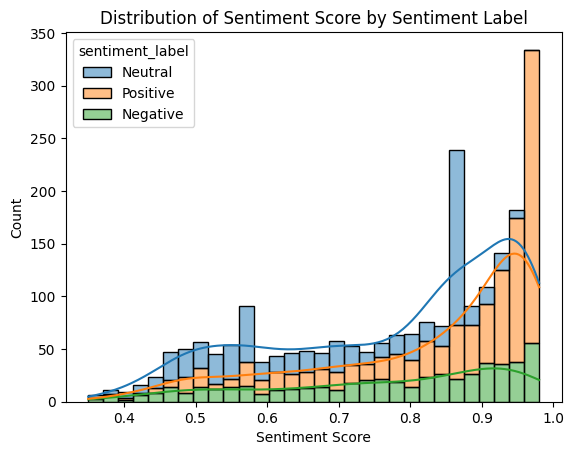

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()

sns.histplot(
    data=df,
    x="sentiment_score",
    hue="sentiment_label",
    bins=30,
    kde=True,
    multiple="stack"
)

plt.title("Distribution of Sentiment Score by Sentiment Label")
plt.xlabel("Sentiment Score")
plt.ylabel("Count")

plt.show()

In [15]:
df.groupby("sentiment_label")["sentiment_score"].agg(
    ["min", "max", "mean"]
).round(3)

,min,max,mean
sentiment_label,,,
Negative,0.35,0.98,0.767
Neutral,0.35,0.95,0.702
Positive,0.37,0.98,0.849


In [16]:
pd.set_option("display.max_columns", None)

# -----------------------------------------
# 3. BASIC DATA INSPECTION
# -----------------------------------------

print("\nINFO DATASET:")
df.info()

print("\nDESCRIBE NUMERICAL:")
df.describe()

print("\nMISSING VALUES:")
missing = df.isnull().sum().sort_values(ascending=False)
print(missing)


INFO DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2215 entries, 0 to 2214
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               2215 non-null   object 
 1   keyword            2215 non-null   object 
 2   url                2215 non-null   object 
 3   content            2129 non-null   object 
 4   username           2215 non-null   object 
 5   total_like         2215 non-null   int64  
 6   total_interaction  2215 non-null   int64  
 7   content_processed  2069 non-null   object 
 8   sentiment_label    2215 non-null   object 
 9   sentiment_score    2215 non-null   float64
 10  post_id            2215 non-null   object 
 11  comment_id         869 non-null    float64
 12  is_comment         2215 non-null   bool   
dtypes: bool(1), float64(2), int64(2), object(8)
memory usage: 209.9+ KB

DESCRIBE NUMERICAL:

MISSING VALUES:
comment_id           1346
content_processed    

#### Username and Post Distribution

In [17]:
# ── Username Stats (Mention-Level) ───────────────────────────────────────────

# Clean username safely
df["username"] = (
    df["username"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
)

# Remove empty usernames
df = df[df["username"] != ""].reset_index(drop=True)

# Basic counts
n_users = df["username"].nunique()
n_rows = len(df)
n_posts = df["post_id"].nunique()

# berapa post berbeda yg menyebut user tsb
posts_per_user = (
    df
    .groupby("username")["post_id"]
    .nunique()
    .sort_values(ascending=False)
)

# berapa comment berbeda yg menyebut user tsb
comments_per_user = (
    df
    .groupby("username")["comment_id"]
    .nunique()
    .sort_values(ascending=False)
)

n_comments = df["comment_id"].nunique()

print(f"Unique usernames : {n_users:,}")
print(f"Unique posts     : {n_posts:,}")
print(f"Total rows       : {n_rows:,}")

# print(f"\nTotal users    : {mentions_per_user}")
# print(f"\nAvg mentions/user: {mentions_per_user.mean():.2f}")
# print(f"Max mentions/user: {mentions_per_user.max()}")
# print(f"Median mentions  : {mentions_per_user.median()}")

# print(f"\nPosts/user       : {posts_per_user}")
print(f"Avg posts/user   : {posts_per_user.mean():.2f}")
print(f"Max posts/user   : {posts_per_user.max()}")
print(f"Median posts     : {posts_per_user.median()}")

print("\nTop 20 most active users (by unique posts):")
print(posts_per_user.head(20).to_string())

print(f"\nUnique comments  : {n_comments:,}")
print(f"Avg comments/user: {comments_per_user.mean():.2f}")
print(f"Max comments/user: {comments_per_user.max()}")
print(f"Median comments  : {comments_per_user.median()}")

print("\nTop 20 most active users (by unique comments):")
print(comments_per_user.head(20).to_string())

Unique usernames : 1,642
Unique posts     : 1,292
Total rows       : 2,215
Avg posts/user   : 1.31
Max posts/user   : 17
Median posts     : 1.0

Top 20 most active users (by unique posts):
username
validnews                     17
sindonews                     14
kapitalismarket               10
investordailyid                8
koranbaliexpress               8
aulia.rahmawati84              8
bitorexpost                    8
zonaebt                        7
otoproject                     7
mediakoranjakarta              7
moltensalt.insight             7
cerah_indonesiaku              6
astrobike.katalog              6
dealovanews.bangkabelitung     5
investingonclimate             5
theglobeconomy                 5
timesindonesia                 5
tututata151                    5
hecktor.03                     5
cobisnis                       4

Unique comments  : 869
Avg comments/user: 0.53
Max comments/user: 5
Median comments  : 0.0

Top 20 most active users (by unique comments):
us

##### Analisis
- Jumlah rows = 2.215. tapi masing-masing unique posts dan unique username jumlahnya < total rows, karena ada comment_id yang refer juga ke username (e.g. comment di suatu post)

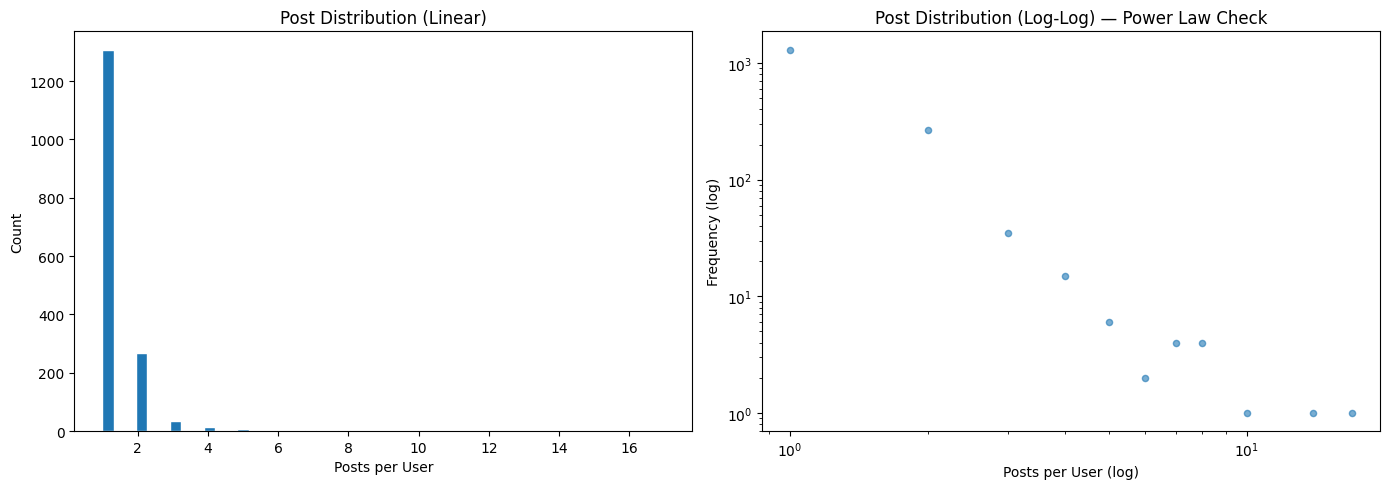

In [18]:
# ── Post Frequency Distribution (Power Law Check) ────────────────────────────

import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

# Pastikan posts_per_user adalah Series numeric
# contoh: posts_per_user = df.groupby("username")["post_id"].nunique()

values = posts_per_user.values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Linear scale histogram
axes[0].hist(
    values,
    bins=50,
    edgecolor="white"
)
axes[0].set_xlabel("Posts per User")
axes[0].set_ylabel("Count")
axes[0].set_title("Post Distribution (Linear)")

# ── Log-log scale (Power law check)
counts = Counter(values)

x = list(counts.keys())
y = list(counts.values())

axes[1].scatter(
    x,
    y,
    alpha=0.6,
    s=20
)

axes[1].set_xscale("log")
axes[1].set_yscale("log")

axes[1].set_xlabel("Posts per User (log)")
axes[1].set_ylabel("Frequency (log)")
axes[1].set_title("Post Distribution (Log-Log) — Power Law Check")

plt.tight_layout()

# ── Save figure safely
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

plt.savefig(
    output_dir / "eda_post_distribution.png",
    bbox_inches="tight"
)

plt.show()

In [19]:
post_distribution = (
    posts_per_user
    .value_counts()
    .sort_index()
)

print(post_distribution.to_string())

post_id
1     1305
2      268
3       35
4       15
5        6
6        2
7        4
8        4
10       1
14       1
17       1


##### Interpretasi:
- 1305 user muncul di tepat 1 post
- 268 user muncul di tepat 2 post
- 35 user muncul di tepat 3 post
- dst
- SUM = unique_username

In [20]:
# ── Parse Date ────────────────────────────────────────────────────────────────
df['date'] = pd.to_datetime(df['date'], errors='coerce')
print(f'Date range: {df["date"].min()} → {df["date"].max()}')
print(f'Null dates: {df["date"].isna().sum()}')

df = df.dropna(subset=['date'])
df['year_month'] = df['date'].dt.to_period('M')
df['day_of_week'] = df['date'].dt.day_name()
df['hour'] = df['date'].dt.hour

Date range: 2026-01-07 13:00:09+00:00 → 2026-04-21 07:27:13+00:00
Null dates: 0


C:\Users\HP\AppData\Local\Temp\ipykernel_20076\1715847533.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['year_month'] = df['date'].dt.to_period('M')


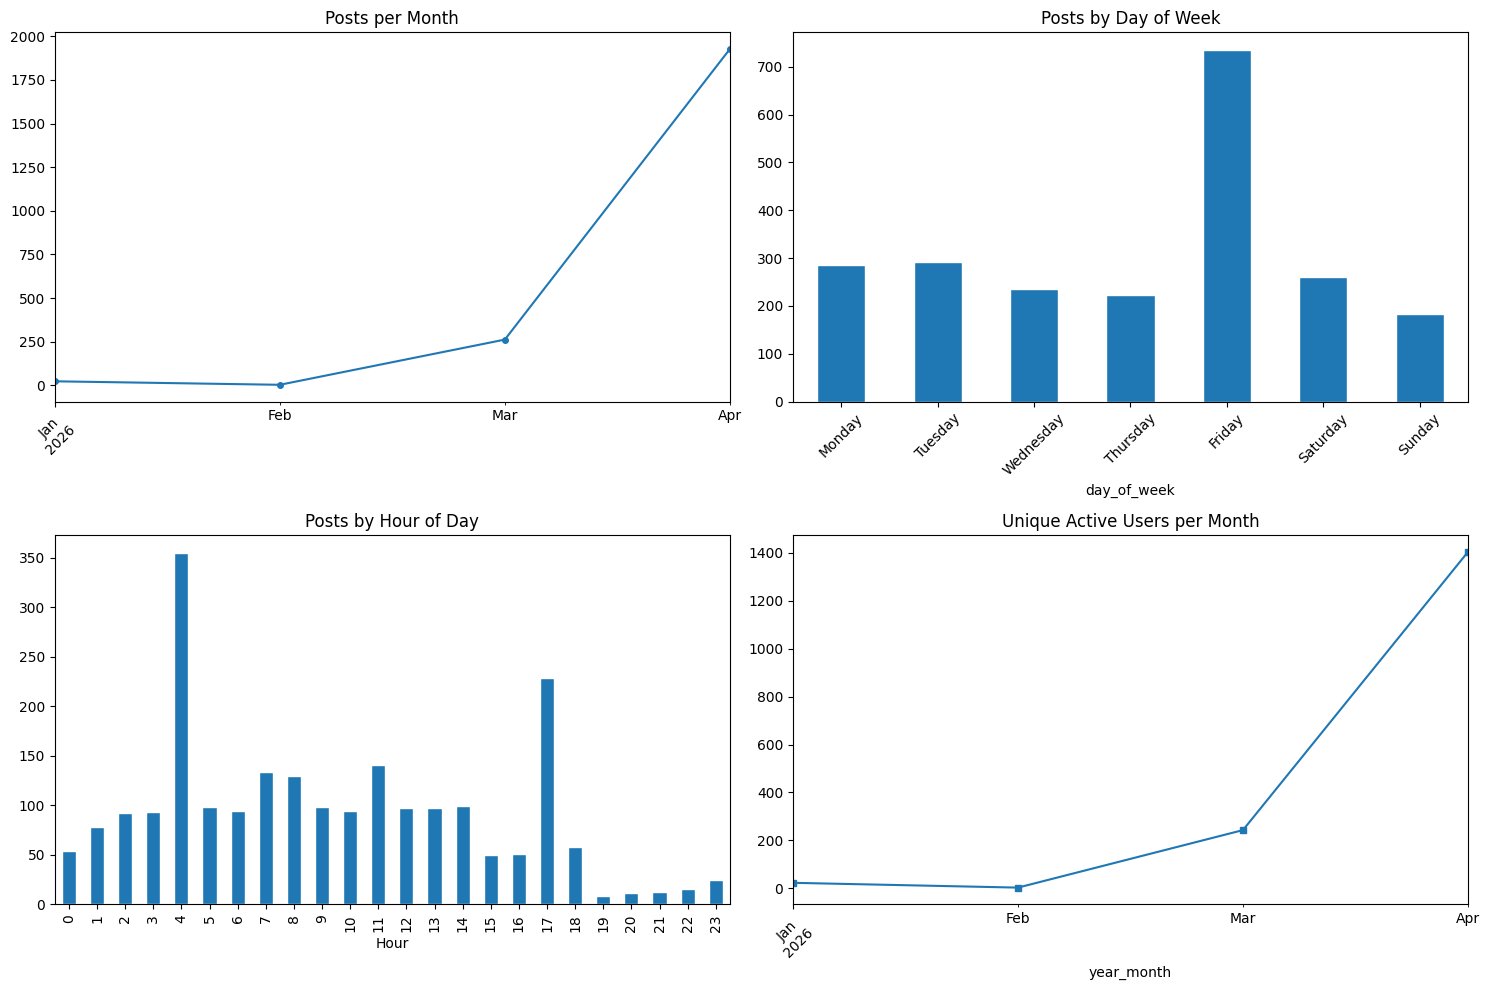

In [21]:
# ── Posts Over Time ───────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
from pathlib import Path

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# ── Monthly trend
monthly = df.groupby("year_month").size()

monthly.plot(
    ax=axes[0, 0],
    marker="o",
    ms=4
)

axes[0, 0].set_title("Posts per Month")
axes[0, 0].set_xlabel("")
axes[0, 0].tick_params(axis="x", rotation=45)

# ── Day of week
dow_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

dow = (
    df["day_of_week"]
    .value_counts()
    .reindex(dow_order)
)

dow.plot(
    kind="bar",
    ax=axes[0, 1],
    edgecolor="white"
)

axes[0, 1].set_title("Posts by Day of Week")
axes[0, 1].tick_params(axis="x", rotation=45)

# ── Hour of day
if "hour" in df.columns:

    hour_counts = (
        df["hour"]
        .value_counts()
        .sort_index()
    )

    hour_counts.plot(
        kind="bar",
        ax=axes[1, 0],
        edgecolor="white"
    )

    axes[1, 0].set_title("Posts by Hour of Day")
    axes[1, 0].set_xlabel("Hour")

else:

    axes[1, 0].set_title("Hour column not available")
    axes[1, 0].axis("off")

# ── Active users per month
monthly_users = (
    df.groupby("year_month")["username"]
    .nunique()
)

monthly_users.plot(
    ax=axes[1, 1],
    marker="s",
    ms=4
)

axes[1, 1].set_title("Unique Active Users per Month")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()

# ── SAFE SAVE (auto-create folder)

output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

plt.savefig(
    output_dir / "eda_temporal.png",
    bbox_inches="tight"
)

plt.show()

##### Cleaning total_like


In [22]:
n_negative_likes = (df["total_like"] == -1).sum()

print("Total rows with total_like = -1:", n_negative_likes)

Total rows with total_like = -1: 48


In [23]:
# ubah jadi NaN, karena mean mengabaikan NaN

df["total_like"] = df["total_like"].replace(-1, 0)

In [24]:
print("Min total_like:", df["total_like"].min())
print("Number of negative likes:",
      (df["total_like"] < 0).sum())
print("Number of zero likes:",
      (df["total_like"] == 0).sum())

Min total_like: 0
Number of negative likes: 0
Number of zero likes: 1048


In [25]:
df["total_like"].isna().sum()

np.int64(0)

In [26]:
df["total_like"] = pd.to_numeric(
    df["total_like"],
    errors="coerce"
)

In [27]:
df["total_like"].describe()

count     2215.000000
mean        70.639729
std        952.185283
min          0.000000
25%          0.000000
50%          1.000000
75%          4.000000
max      35229.000000
Name: total_like, dtype: float64

##### Analisis:
- sebagian besar postingan ngga punya like
- ada outlier, max = 35,229 => std sangat besar

In [28]:
df[df["total_like"].isna()].head(10)

,date,keyword,url,content,username,total_like,total_interaction,content_processed,sentiment_label,sentiment_score,post_id,comment_id,is_comment,year_month,day_of_week,hour


In [29]:
# ubah NaN jadi 0
df["total_like"] = df["total_like"].fillna(0)

In [30]:
# pastikan numeric
df["total_like"] = pd.to_numeric(
    df["total_like"],
    errors="coerce"
)

# ubah NaN jadi 0
df["total_like"] = df["total_like"].fillna(0)

In [31]:
print("Missing values:", df["total_like"].isna().sum())
print("Min total_like:", df["total_like"].min())

Missing values: 0
Min total_like: 0


##### Interaction Metric Analysis

In [32]:
# ── Numeric Stats ─────────────────────────────────────────

import pandas as pd

pd.set_option("display.max_columns", None)

interaction_cols = [
    "total_like",
    "total_interaction"
]

# Check kolom yang benar-benar ada
existing_cols = [
    c for c in interaction_cols
    if c in df.columns
]

if len(existing_cols) == 0:

    print("No interaction columns found.")

else:

    # Convert ke numeric
    for col in existing_cols:

        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

        # Optional: ubah missing jadi 0
        df[col] = df[col].fillna(0)

    print("Interaction Metrics Summary:")

    print(
        df[existing_cols]
        .describe(
            percentiles=[.25, .5, .75, .9, .95, .99]
        )
        .round(2)
    )

    print("\nCorrelation Matrix:")

    print(
        df[existing_cols]
        .corr()
        .round(3)
    )

print("\nINFO DATASET:")
df.info()

print("\nDESCRIBE NUMERICAL:")
df.describe()

print("\nMISSING VALUES:")
missing = df.isnull().sum().sort_values(ascending=False)
print(missing)

Interaction Metrics Summary:
       total_like  total_interaction
count     2215.00            2215.00
mean        70.64               0.75
std        952.19               4.86
min          0.00               0.00
25%          0.00               0.00
50%          1.00               0.00
75%          4.00               0.00
90%         38.60               1.00
95%        117.30               3.00
99%       1191.74              16.86
max      35229.00             131.00

Correlation Matrix:
                   total_like  total_interaction
total_like              1.000              0.041
total_interaction       0.041              1.000

INFO DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2215 entries, 0 to 2214
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   date               2215 non-null   datetime64[ns, UTC]
 1   keyword            2215 non-null   object           

##### Analisis:
- distribusi sangat skewed
- engagement post (comment) rendah, karena total interaction dihitung dari engagement suatu comment
- hanya 1% post yang punya total_interactions
- 50% postingan punya total like = 1
- 75% post punya ≤ 4 like
- 99% = 1191 => hanya 1% post yang benar-benar high engagement
- Max = 35,229 => outlier / viral post

##### Analisis Korelasi:
- hampir tidak ada korelaso antara total_likes and total_interactions (0.041)

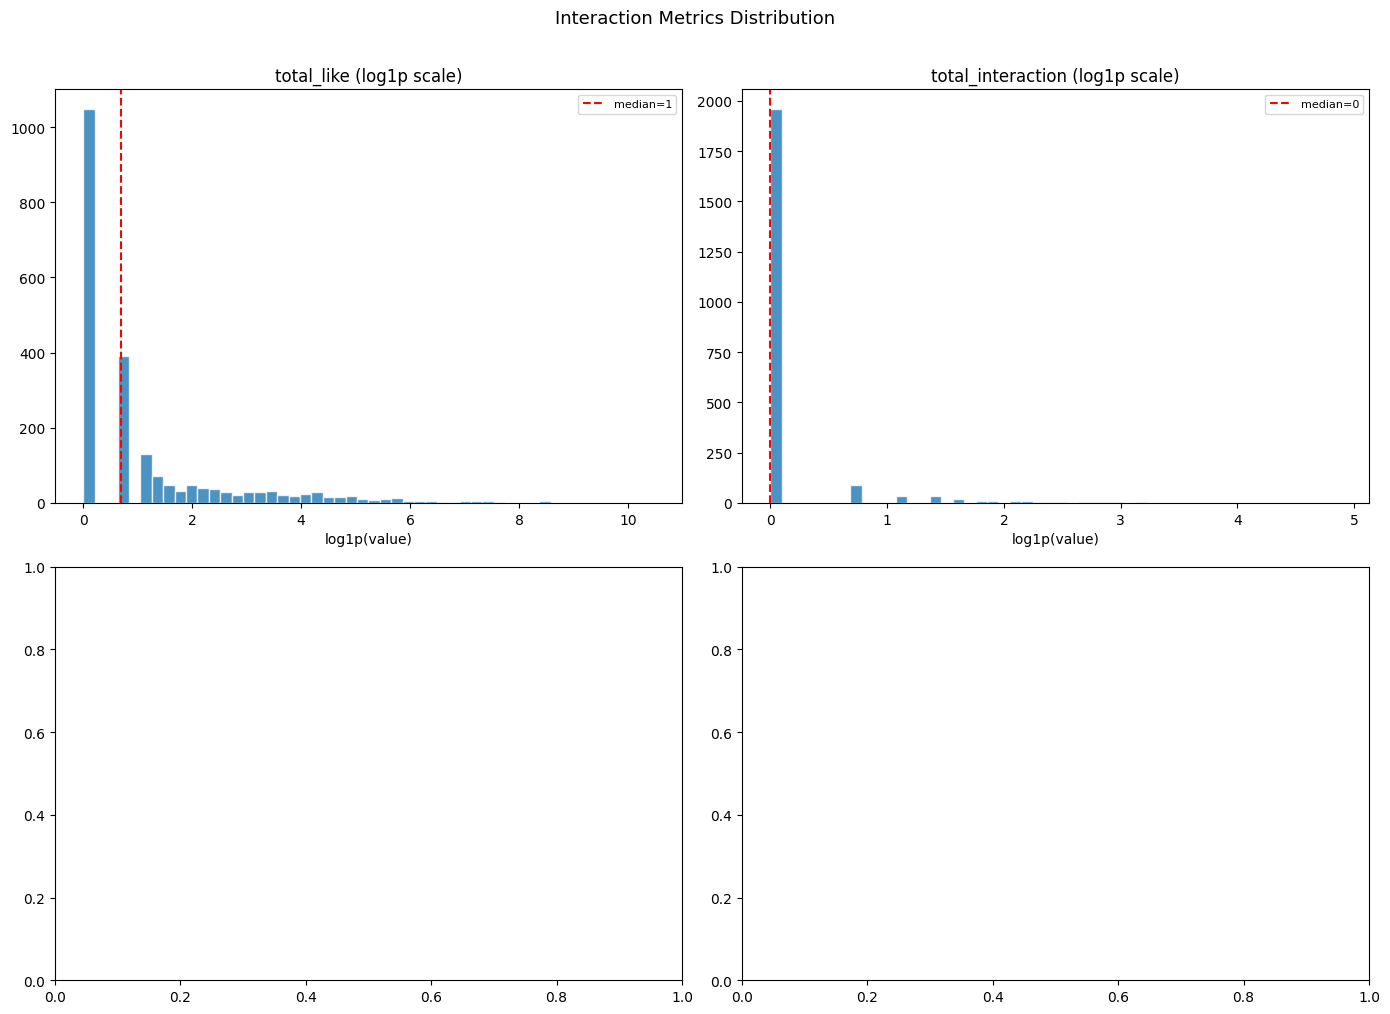

In [33]:
# ── Interaction Distribution (Log Scale) ─────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors = [
    "steelblue",
    "coral",
    "mediumseagreen",
    "mediumpurple"
]

for ax, col, color in zip(axes.flatten(), existing_cols, colors):

    # Convert to numeric safely
    data = pd.to_numeric(
        df[col],
        errors="coerce"
    )

    # Remove invalid values
    data = data[
        (data >= 0) &
        np.isfinite(data)
    ].dropna()

    if len(data) == 0:

        ax.set_title(f"{col} (no valid data)")
        ax.axis("off")
        continue

    # Log transform
    data_log = np.log1p(data)

    # Plot
    ax.hist(
        data_log,
        bins=50,
        edgecolor="white",
        alpha=0.8
    )

    ax.set_title(f"{col} (log1p scale)")
    ax.set_xlabel("log1p(value)")

    # Median line
    median_val = data.median()

    ax.axvline(
        np.log1p(median_val),
        color="red",
        linestyle="--",
        label=f"median={median_val:.0f}"
    )

    ax.legend(fontsize=8)

plt.suptitle(
    "Interaction Metrics Distribution",
    fontsize=13,
    y=1.01
)

plt.tight_layout()

# Safe save
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

plt.savefig(
    output_dir / "eda_interactions.png",
    bbox_inches="tight"
)

plt.show()

In [34]:
# ubah comment_id dan post_id jadi string
# ── Convert ID columns to STRING safely ─────────────────────────────────────

import pandas as pd

id_columns = ["post_id", "comment_id"]

for col in id_columns:

    if col in df.columns:

        if col == "comment_id":

            # Handle float / scientific notation safely
            df[col] = (
                pd.to_numeric(
                    df[col],
                    errors="coerce"
                )
                .astype("Int64")     # nullable integer
                .astype(str)         # convert to string
                .replace("<NA>", "") # remove missing
            )

        else:

            # Simpler conversion for post_id
            df[col] = (
                df[col]
                .fillna("")
                .astype(str)
            )

# ── Quick validation ───────────────────────────────────────────────────────

for col in id_columns:

    if col in df.columns:

        print(f"{col} dtype:", df[col].dtype)

        print(
            f"{col} scientific notation count:",
            df[col].str.contains("e", case=False).sum()
        )

        print(df[col].head())
        print("-" * 40)

post_id dtype: object
post_id scientific notation count: 885
0    DXRbGtZDWwE
1    DXQ9vlVgfYv
2    DXQ7004CSOe
3    DXQvXjDibxG
4    DXQYunJjZoJ
Name: post_id, dtype: object
----------------------------------------
comment_id dtype: object
comment_id scientific notation count: 0
0    
1    
2    
3    
4    
Name: comment_id, dtype: object
----------------------------------------


In [35]:
# ── Check scientific notation properly ─────────────────────────

import re

pattern = r"\d+\.?\d*e[+-]?\d+"

for col in ["post_id", "comment_id"]:

    if col in df.columns:

        count = df[col].astype(str).str.contains(
            pattern,
            case=False,
            regex=True
        ).sum()

        print(f"{col} scientific notation count:", count)

post_id scientific notation count: 27
comment_id scientific notation count: 0


In [36]:
import re

pattern = r"\d+\.?\d*e[+-]?\d+"

bad_post_ids = df[
    df["post_id"]
    .astype(str)
    .str.contains(pattern, case=False, regex=True)
]["post_id"]

print("Sample problematic post_id:")
print(bad_post_ids.head(10))

Sample problematic post_id:
19     DWjTzN7E5oW
302    DVf5hC7E4As
311    DTg8eZ8E23w
314    DXEnOK0E0lZ
320    DUR_b11E4Vo
325    DXW6GP5E8mN
370    DXNvKt7E6Xx
388    DXJXnO7E3Zs
453    DW9e8nvk29r
725    DW61e5jE0Ip
Name: post_id, dtype: object


In [37]:
import re

# Scientific notation harus dimulai dari angka
pattern = r"^\d+\.?\d*e[+-]?\d+$"

bad_post_ids = df[
    df["post_id"]
    .astype(str)
    .str.contains(pattern, case=False, regex=True)
]["post_id"]

print("Scientific notation post_id count:", len(bad_post_ids))
print(bad_post_ids.head())

Scientific notation post_id count: 0
Series([], Name: post_id, dtype: object)


In [38]:
pd.set_option("display.max_columns", None)

# -----------------------------------------
# 3. BASIC DATA INSPECTION
# -----------------------------------------

print("\nINFO DATASET:")
df.info()

print("\nDESCRIBE NUMERICAL:")
df.describe()

print("\nMISSING VALUES:")
missing = df.isnull().sum().sort_values(ascending=False)
print(missing)


INFO DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2215 entries, 0 to 2214
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   date               2215 non-null   datetime64[ns, UTC]
 1   keyword            2215 non-null   object             
 2   url                2215 non-null   object             
 3   content            2129 non-null   object             
 4   username           2215 non-null   object             
 5   total_like         2215 non-null   int64              
 6   total_interaction  2215 non-null   int64              
 7   content_processed  2069 non-null   object             
 8   sentiment_label    2215 non-null   object             
 9   sentiment_score    2215 non-null   float64            
 10  post_id            2215 non-null   object             
 11  comment_id         2215 non-null   object             
 12  is_comment         2215 non-null 

In [39]:
# ── Pisahkan posts dan comments ───────────────────────────────────────────
posts    = df[df['is_comment'] == False].copy()
comments = df[df['is_comment'] == True].copy()

# ── Post lookup: post_id → owner + like postingan ─────────────────────────
post_lookup = (
    posts[['post_id', 'username', 'total_like', 'total_interaction']]
    .drop_duplicates('post_id')
    .rename(columns={
        'username':          'post_owner_username',
        'total_like':        'post_like',
        'total_interaction': 'post_interaction',
    })
)

# ── Comment rows ───────────────────────────────────────────────────────────
comment_edges = (
    comments[['username', 'post_id', 'comment_id', 'total_like']]
    .rename(columns={
        'username':   'commenter_username',
        'total_like': 'comment_like',
    })
)

# ── JOIN: comment → post ───────────────────────────────────────────────────
merged = comment_edges.merge(post_lookup, on='post_id', how='inner')

# Buang self-loop
merged = merged[merged['commenter_username'] != merged['post_owner_username']]

# ── Aggregate per post_id ──────────────────────────────────────────────────
post_rank = (
    merged
    .groupby(['post_id', 'post_owner_username'], as_index=False)
    .agg(
        comment_count    = ('comment_id',         'count'),
        unique_commenters= ('commenter_username',  'nunique'),
        total_comment_like=('comment_like',        'sum'),
        post_like        = ('post_like',           'first'),
        post_interaction = ('post_interaction',    'first'),
        comment_id_list  = ('comment_id',          lambda x: sorted(set(x))),
        commenter_list   = ('commenter_username',  lambda x: sorted(set(x))),
    )
)

# ── Attach count_post per owner (berapa total post milik akun itu) ─────────
count_post = (
    post_lookup
    .groupby('post_owner_username', as_index=False)
    .agg(count_post=('post_id', 'nunique'))
)

post_rank = post_rank.merge(count_post, on='post_owner_username', how='left')

# ── Reorder kolom & sort ───────────────────────────────────────────────────
post_rank = (
    post_rank[[
        'post_id',
        'post_owner_username',
        'count_post',
        'comment_count',
        'unique_commenters',
        'total_comment_like',
        'post_like',
        'post_interaction',
        'comment_id_list',
        'commenter_list',
    ]]
    .sort_values(['post_owner_username', 'comment_count'], ascending=[True, False])
)

print(f"Total posts with comments : {len(post_rank):,}")
print(f"Unique post owners        : {post_rank['post_owner_username'].nunique():,}")
print()
print(post_rank.head(20).to_string(index=False))

# ── Save ───────────────────────────────────────────────────────────────────
post_rank.to_csv('../data/processed/post_comment_rank.csv', index=False)
print("\n✅ Saved: post_comment_rank.csv")

Total posts with comments : 190
Unique post owners        : 123

    post_id post_owner_username  count_post  comment_count  unique_commenters  total_comment_like  post_like  post_interaction                                                                                                                                                                                comment_id_list                                                                                                                                                commenter_list
DWub4RBAX-U        agam.munawar           1              1                  1                   0         47                 0                                                                                                                                                                            [18358255525224176]                                                                                                                                              

In [44]:
from pathlib import Path

def build_comment_edge_dataset(df, output_dir="output"):

    print("Function started")

    output_path = Path(output_dir)
    output_path.mkdir(exist_ok=True)

    # Filter comments

    df_comments = df[
        df["is_comment"] == True
    ].copy()

    print("Total comments:", len(df_comments))

    # Mention count

    if "n_mentions" in df_comments.columns:

        df_comments["mention_count"] = (
            df_comments["n_mentions"]
            .fillna(0)
            .astype(int)
        )

    elif "mentions" in df_comments.columns:

        df_comments["mention_count"] = (
            df_comments["mentions"]
            .fillna("")
            .apply(
                lambda x: len(x.split("|"))
                if x != ""
                else 0
            )
        )

    else:

        df_comments["mention_count"] = 0

    # Commenter

    df_comments["commenter_username"] = (
        df_comments["username"]
    )

    # Post owner

    df_post_owner = (
        df[df["is_comment"] == False]
        [["post_id", "username"]]
        .rename(
            columns={
                "username": "post_owner_username"
            }
        )
    )

    df_comments = df_comments.merge(
        df_post_owner,
        on="post_id",
        how="left"
    )

    # Ensure numeric

    df_comments["total_interaction"] = (
        df_comments["total_interaction"]
        .fillna(0)
        .astype(int)
    )

    df_comments["total_like"] = (
        df_comments["total_like"]
        .fillna(0)
        .astype(int)
    )

    # Final dataset

    df_comment_edges = df_comments[
        [
            "comment_id",
            "post_id",
            "commenter_username",
            "post_owner_username",
            "mention_count",
            "total_interaction",
            "total_like"
        ]
    ].copy()

    # Save

    file_path = output_path / "comment_edge_dataset.csv"

    df_comment_edges.to_csv(
        file_path,
        index=False,
        encoding="utf-8-sig"
    )

    print("comment_edge_dataset saved")
    print("Location:", file_path.resolve())
    print("Rows:", len(df_comment_edges))

    return df_comment_edges

In [45]:
df_comment_edges = build_comment_edge_dataset(df)

Function started
Total comments: 869
comment_edge_dataset saved
Location: D:\Intern - Project Assignment\sna_ig\pre-processing\dataset\output\comment_edge_dataset.csv
Rows: 887


In [ ]:
# ── Total komentar yang diterima per post owner ───────────────────────────
comments_received = (
    merged
    .groupby('post_owner_username', as_index=False)
    .agg(total_comments_received=('comment_id', 'count'))
    .rename(columns={'post_owner_username': 'username'})
    .sort_values('total_comments_received', ascending=False)
)

print(f"Total post owners : {len(comments_received):,}")
print(comments_received.head(20).to_string(index=False))

comments_received.to_csv('../data/processed/user_comments_received.csv', index=False)
print("\n✅ Saved: user_comments_received.csv")

Total post owners : 123
          username  total_comments_received
         sindonews                       79
moltensalt.insight                       42
        otoproject                       39
       bitorexpost                       38
           metrotv                       30
       luarbioskop                       29
  koranbaliexpress                       26
   investordailyid                       20
         kompascom                       20
 sukabumiupdatecom                       19
 feedcollective.co                       16
      katadatacoid                       16
  bloombergtechnoz                       15
    timesindonesia                       14
 cerah_indonesiaku                       11
 astrobike.katalog                       11
       trendjktcom                       10
   officialinewstv                       10
     tommybr_jipro                       10
        katakitaig                       10

✅ Saved: user_comments_received.csv


In [ ]:
# ── Interaction Coverage Check ─────────────────────────────────────────────

# Total rows
total = len(df)

# Missing interaction
null_interaction = df["total_interaction"].isna().sum()

# Coverage
coverage = (total - null_interaction) / total * 100

print(
    f"total_interaction coverage: "
    f"{coverage:.1f}% "
    f"({total-null_interaction:,}/{total:,} rows)"
)

# Zero interaction
zero_interaction = (
    df["total_interaction"] == 0
).sum()

print(
    f"Posts with 0 interaction : "
    f"{zero_interaction:,}"
)

# Additional clarity
print(
    f"Missing interaction      : "
    f"{null_interaction:,}"
)

# Users with missing interaction
if null_interaction > 0:

    missing_by_user = (
        df[
            df["total_interaction"].isna()
        ]["username"]
        .value_counts()
    )

    print(
        "\nUsers with most missing interactions (top 10):"
    )

    print(
        missing_by_user
        .head(10)
    )

else:

    print(
        "\nNo missing total_interaction values."
    )

total_interaction coverage: 100.0% (2,215/2,215 rows)
Posts with 0 interaction : 1,959
Missing interaction      : 0

No missing total_interaction values.


##### Analisis:
- ≈ 88.4% post memiliki 0 interaction
- ≈ 11.6% post memiliki interaction > 0

In [ ]:
# lowercase all username/mention
# ── Extract @mentions dan #hashtags (exclude emails) ─────────────────────────

import re
import pandas as pd

# Validate column
if "content" not in df.columns:
    raise ValueError("Column 'content' not found in dataframe.")

print("Using content column: content")

# Pre-compile regex

MENTION_PATTERN = re.compile(
    r"@([A-Za-z0-9_.]+)"
)

HASHTAG_PATTERN = re.compile(
    r"#([A-Za-z0-9_]+)"
)

# Domain indicators for email
EMAIL_DOMAINS = (
    ".com",
    ".co",
    ".id",
    ".net",
    ".org",
    ".ac",
    ".edu"
)

# Functions

def extract_mentions(text):

    if pd.isna(text):
        return []

    mentions = MENTION_PATTERN.findall(
        str(text)
    )

    cleaned = []

    for m in mentions:

        m_lower = m.lower()

        # Exclude email-like patterns
        if any(domain in m_lower for domain in EMAIL_DOMAINS):
            continue

        cleaned.append(m_lower)

    return list(sorted(set(cleaned)))


def extract_hashtags(text):

    if pd.isna(text):
        return []

    hashtags = HASHTAG_PATTERN.findall(
        str(text)
    )

    return list(
        sorted(
            set(
                h.lower()
                for h in hashtags
            )
        )
    )

# Apply extraction

df["mentions"] = df["content"].apply(
    extract_mentions
)

df["hashtags"] = df["content"].apply(
    extract_hashtags
)

# Count

df["n_mentions"] = df["mentions"].apply(len)

df["n_hashtags"] = df["hashtags"].apply(len)

# Quick summary

print("\nSummary:")

print(
    "Total mentions found :",
    df["n_mentions"].sum()
)

print(
    "Total hashtags found :",
    df["n_hashtags"].sum()
)

print(
    "\nRows with mentions :",
    (df["n_mentions"] > 0).sum()
)

print(
    "Rows with hashtags :",
    (df["n_hashtags"] > 0).sum()
)

Using content column: content

Summary:
Total mentions found : 129
Total hashtags found : 8591

Rows with mentions : 84
Rows with hashtags : 1278


##### Analisis
- Total rows = 2,215, persentase rows yang punya mentions = 84 / 2215 = 3.8% (sekitar 3-4 mention per post)
- Hashtags (rows) = 1278 / 2215 = 57.7% 
- Hashtag per post = 8591 / 1278 = 6.7 hashtags per post (sekitar 6–7 hashtag per post)

In [ ]:
df["post_id"].duplicated().any()

np.True_

In [ ]:
df[df["n_mentions"] > 0][
    ["content", "mentions"]
].head(10)

,content,mentions
10,Jangan Biarkan Pemimpin Ikhlas Berjuang Seoran...,[prabowo]
62,Kenaikan tajam BBM non-subsidi resmi berlaku. ...,[voxnetizens]
63,Kenaikan tajam BBM non-subsidi resmi berlaku. ...,[storyrakyat_]
64,Kenaikan tajam BBM non-subsidi resmi berlaku. ...,[wartaekonomi]
65,Kenaikan tajam BBM non-subsidi resmi berlaku. ...,[energinewsid]
66,Kenaikan tajam BBM non-subsidi resmi berlaku. ...,[kesdm]
67,Kenaikan tajam BBM non-subsidi resmi berlaku. ...,[pertaminapatraniaga]
68,Kenaikan tajam BBM non-subsidi resmi berlaku. ...,[pertamina.foundation]
69,Kenaikan tajam BBM non-subsidi resmi berlaku. ...,[pertamina]
172,"Pak @prabowo, dan Pak @bahlillahadalia kehadir...","[bahlillahadalia, prabowo]"


In [ ]:
df[df["n_hashtags"] > 0][
    ["content", "hashtags"]
].head(10)

,content,hashtags
0,PT Pertamina (Persero) resmi menaikkan harga s...,"[dpr, hargabbm, kenaikanhargabbm]"
1,Resmi ! Pertamina naikkan harga BBM nonsubsidi...,"[bbmnonsubsidi, beritaterkini, beritaviral, ke..."
2,"Kenaikan harga bahan bakar kembali terjadi, de...","[bogor, bogorinsider, kenaikanhargabbm]"
3,📝 Berbagi info....❗ PT Pertamina (Persero) men...,"[hargabbmsaatini, kenaikanhargabbm, pengikut]"
4,PT Pertamina (Persero) menaikkan harga sejumla...,"[bahanbakarminyak, bbm, bbmsubsidi, beritavira..."
5,"Hallo Sahabat Oto! Di pertengahan April ini, P...","[beritaotomotif, beritaotoproject, hargabbmapr..."
6,Wow wow wow 🤟😅😅😅 Kenaikan harga BBM. Asik nih....,"[bbm, jualbelimobilbekas, kenaikanhargabbm]"
7,"Menteri Haji dan Umrah (Menhaj) RI, Gus Irfan ...","[alhamdulilah, biayahaji, hajiumroh, ibadahhaj..."
8,"RRI.CO.ID, Jakarta - Pemerintah memastikan har...","[bbm, bbmsubsidi, beritarri, ekonomiindonesia,..."
9,"-- 𝙆𝙚𝙣𝙖𝙞𝙠𝙖𝙣 𝙃𝙖𝙧𝙜𝙖 𝘽𝘽𝙈 𝘽𝙞𝙨𝙖 𝙋𝙞𝙘𝙪 𝙂𝙚𝙟𝙤𝙡𝙖𝙠, 𝙋𝙚𝙣𝙜𝙖...","[ekonomiindonesia, kenaikanhargabbm, prabowosu..."


In [ ]:
# ── Mention Statistics ────────────────────────────────────────────────────────
posts_with_mentions = (df['n_mentions'] > 0).sum()
total_mentions = df['n_mentions'].sum()

print(f'Posts with ≥1 mention  : {posts_with_mentions:,} ({posts_with_mentions/len(df)*100:.1f}%)')
print(f'Total mentions found   : {total_mentions:,}')
print(f'Avg mentions per post  : {total_mentions/len(df):.2f}')
print(f'Max mentions in 1 post : {df["n_mentions"].max()}')

# All mentioned usernames
all_mentions = [m.lower() for mentions in df['mentions'] for m in mentions]
mention_counter = Counter(all_mentions)

print(f'\nUnique mentioned usernames: {len(mention_counter):,}')
print('\nTop 30 most mentioned users:')
for user, count in mention_counter.most_common(30):
    print(f'  @{user}: {count}')

Posts with ≥1 mention  : 84 (3.8%)
Total mentions found   : 129
Avg mentions per post  : 0.06
Max mentions in 1 post : 10

Unique mentioned usernames: 97

Top 30 most mentioned users:
  @prabowo: 9
  @riyan.nurrahman: 6
  @bahlillahadalia: 5
  @alif.m.ismail: 3
  @kompascom: 3
  @bloombergtechnoz: 3
  @kesdm: 2
  @pertamina: 2
  @arroyyanmas: 2
  @ditlitka.ppidunia: 2
  @pembuat_jejak25: 2
  @ppidunia: 2
  @yuliawati.792: 2
  @satya.bumi: 2
  @dpr_ri: 2
  @voxnetizens: 1
  @storyrakyat_: 1
  @wartaekonomi: 1
  @energinewsid: 1
  @pertaminapatraniaga: 1
  @pertamina.foundation: 1
  @asep19_: 1
  @purbayayudhi.official: 1
  @sorotan: 1
  @metrotv: 1
  @infoterkinimu: 1
  @milenianews: 1
  @matanajwa: 1
  @enviroxiland2026: 1
  @hmtl.undip: 1


In [ ]:
posts_max_mentions = (
    df[df["n_mentions"] == df["n_mentions"].max()]
    .sort_values("n_mentions", ascending=False)
)


pd.set_option("display.max_colwidth", None)

print(
    df.loc[
        df["n_mentions"] == df["n_mentions"].max(),
        ["post_id", "username", "n_mentions", "mentions", "content"]
    ]
)

          post_id                     username  n_mentions  \
1454  DXEPjo_ismE  merchandise_original_persib          10   

                                                                                                                                          mentions  \
1454  [djed.komdigi, dpr_ri, gibran_rakabuming, gojekindonesia, grabid, kemenhub151, ketua_dprri, literasidigitalkomdigi, perekonomianri, prabowo]   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

##### Analisis:
- Hanya ada 1 post_id yang punya 10 mentions, itu di comment

In [ ]:
# ── Build Edge List from Mentions ─────────────────────────────────────────────

import pandas as pd
from pathlib import Path

# Pastikan kolom mentions ada
if "mentions" not in df.columns:
    raise ValueError("Column 'mentions' not found. Run extraction step first.")

edges_mention = []

for _, row in df.iterrows():
    poster = str(row.get("username", "")).lower().strip()
    mentions_list = row.get("mentions", [])

    if not isinstance(mentions_list, list):
        continue

    for mentioned in mentions_list:
        mentioned = str(mentioned).lower().strip()

        if mentioned and mentioned != poster:

            edges_mention.append({
                "source": poster,
                "target": mentioned,
                "date": str(row.get("date", "")),
                "type": "mention",
                "post_interaction": row.get(
                    "total_interaction",
                    0
                )
            })

edges_df = pd.DataFrame(edges_mention)

print(f"Total mention-based edges: {len(edges_df):,}")

# ── Aggregate edges (weight)
if len(edges_df) > 0:

    edges_agg = (
        edges_df
        .groupby(["source", "target"])
        .agg(
            weight=("type", "count"),
            avg_interaction=("post_interaction", "mean")
        )
        .reset_index()
        .sort_values("weight", ascending=False)
    )

    print(f"Unique directed edges    : {len(edges_agg):,}")

    print("\nTop 20 strongest edges:")
    print(
        edges_agg
        .head(20)
        .to_string(index=False)
    )

    # ── SAFE SAVE ─────────────────────────────────

    output_dir = Path("output")
    output_dir.mkdir(exist_ok=True)

    file_path = output_dir / "edges_mention.csv"

    edges_agg.to_csv(
        file_path,
        index=False
    )

    print(f"\n✅ Saved to {file_path}")

else:

    print("\n⚠️  NO MENTIONS FOUND in content!")
    print("→ SNA will need to use co-keyword network as primary edge source")
    print("→ See Section 8: Network Feasibility")

Total mention-based edges: 106
Unique directed edges    : 99

Top 20 strongest edges:
            source               target  weight  avg_interaction
             350id      bahlillahadalia       3              0.0
             350id              prabowo       3              0.0
 ditlitka.ppidunia             ppidunia       2              0.0
 ditlitka.ppidunia      pembuat_jejak25       2              0.0
 ditlitka.ppidunia          arroyyanmas       2              0.0
             350id   haniffaisolnurofiq       1              0.0
      ________naba      riyan.nurrahman       1              1.0
     arafatsaid765              sorotan       1              0.0
         aan101425              prabowo       1              4.0
           aelav.u        yuliawati.792       1              0.0
         aktualcom          aktualforum       1              0.0
 aulia.rahmawati84            pertamina       1              0.0
 aulia.rahmawati84 pertamina.foundation       1              0.0
 aul

In [ ]:
dup_inside_post = df["mentions"].apply(
    lambda x: len(x) != len(set(x))
    if isinstance(x, list)
    else False
).sum()

print("Posts with duplicate mentions inside:", dup_inside_post)

Posts with duplicate mentions inside: 0


In [ ]:
print("Raw edges:", len(edges_df))

print(
    "Unique edges:",
    edges_df.groupby(["source", "target"]).ngroups
)

Raw edges: 106
Unique edges: 99


##### Analisis:
- Jumlah total mention event = 106
- Misal : 
    - A → B   (post 1)
    - A → B   (post 2)
    - A → C
- Maka, raw edges = 3
- Unique edges = 99
- Ada 7 hubungan yang terjadi lebih dari sekali


In [ ]:
repeated_edges = (
    edges_df
    .groupby(["source", "target"])
    .size()
    .reset_index(name="weight")
    .query("weight > 1")
    .sort_values("weight", ascending=False)
)

print(repeated_edges)

               source           target  weight
0               350id  bahlillahadalia       3
2               350id          prabowo       3
27  ditlitka.ppidunia      arroyyanmas       2
28  ditlitka.ppidunia  pembuat_jejak25       2
29  ditlitka.ppidunia         ppidunia       2


In [ ]:
# ── Hashtag Analysis ──────────────────────────────────────────────────────────
# possible buat 1 post ada >1 hashtag, kita hitung semua hashtag walaupun duplikat

from collections import Counter
from pathlib import Path
import pandas as pd

# Pastikan kolom hashtags ada
if "hashtags" not in df.columns:
    raise ValueError("Column 'hashtags' not found.")

# Flatten hashtags safely
all_hashtags = []

for tags in df["hashtags"]:

    if isinstance(tags, list):

        all_hashtags.extend(
            [str(h).lower().strip() for h in tags if h]
        )

hashtag_counter = Counter(all_hashtags)

print(f"Posts with ≥1 hashtag  : {(df['n_hashtags'] > 0).sum():,}")
print(f"Unique hashtags        : {len(hashtag_counter):,}")

print("\nTop 30 hashtags:")

for tag, count in hashtag_counter.most_common(30):
    print(f"  #{tag}: {count}")

# ── Prepare export dataset ─────────────────────────────────

df["hashtags_str"] = df["hashtags"].apply(
    lambda x: "|".join(
        [str(h).lower().strip() for h in x]
    ) if isinstance(x, list) else ""
)

# Safe save
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

file_path = output_dir / "posts_with_meta.csv"

df[
    ["username", "date", "hashtags_str", "mentions"]
].to_csv(
    file_path,
    index=False
)

print(f"\n✅ Saved to {file_path}")

Posts with ≥1 hashtag  : 1,278
Unique hashtags        : 1,609

Top 30 hashtags:
  #krisisenergi: 525
  #transisienergi: 483
  #indonesiamaju: 363
  #subsidibbm: 317
  #energibersih: 302
  #kemandirianenergi: 288
  #ketahananenergi: 243
  #energiterbarukan: 227
  #prabowosubianto: 226
  #ekonomiindonesia: 121
  #geopolitik: 112
  #bbm: 100
  #energinasional: 99
  #selathormuz: 98
  #beritaterkini: 95
  #energiindonesia: 80
  #iran: 74
  #indonesiasiap: 72
  #timurtengah: 70
  #ketahanannasional: 69
  #hargaminyak: 68
  #prabowo: 67
  #masadepanenergi: 65
  #hargabbm: 59
  #indonesiaberdaulat: 52
  #magelang: 52
  #kedaulatanbangsa: 47
  #literasienergi: 44
  #potensilokal: 37
  #pertamina: 36

✅ Saved to output\posts_with_meta.csv


In [ ]:
dup_hashtag_posts = df["hashtags"].apply(
    lambda x: len(x) != len(set(x))
    if isinstance(x, list)
    else False
).sum()

print("Posts with duplicate hashtags inside:", dup_hashtag_posts)

Posts with duplicate hashtags inside: 0


##### Sentiment Analysis

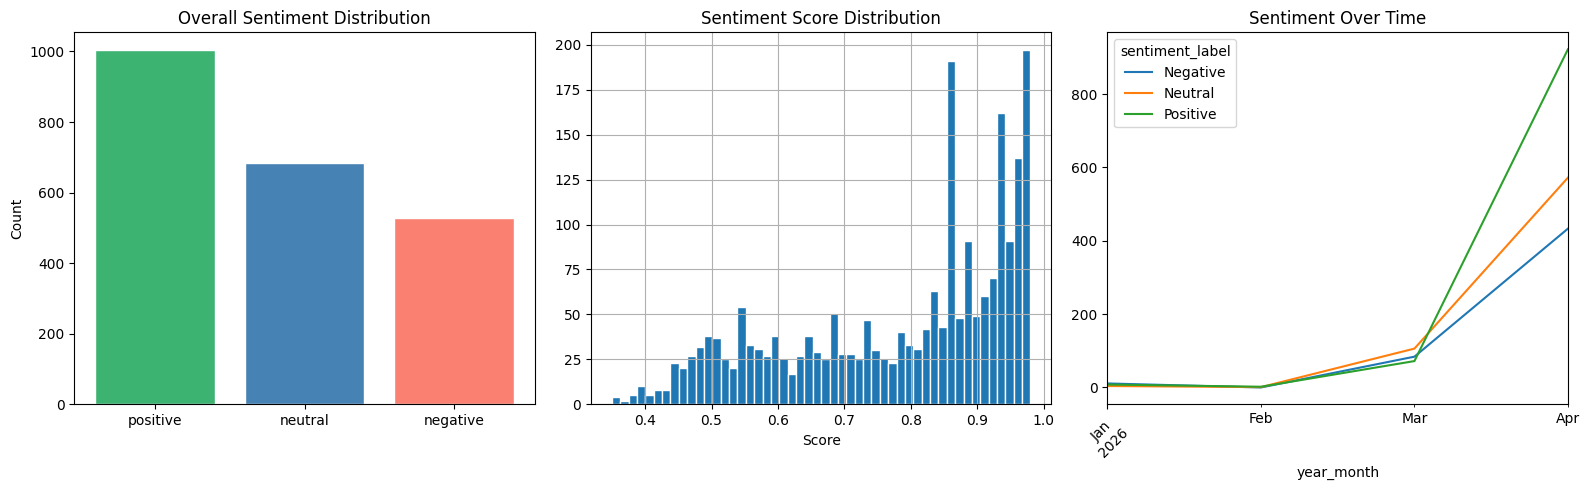


✅ Saved to output\eda_sentiment.png

Top 10 users with most negative posts:
username
aulia.rahmawati84      8
koranbaliexpress       7
sindonews              6
tututata151            5
idnpolicy              3
dd_cerdas              3
priangan_com           3
tumbuhkaya.id          3
unpacking.indonesia    3
validnews              3
dtype: int64

Sentiment breakdown per keyword:
sentiment_label   Negative  Neutral  Positive
keyword                                      
HargaMinyakBumi          0        1         0
KenaikanhargaBBM         3       28         5
KonsumsiBBM              0        3         3
KrisisEnergi           140      127       233
MinyakIndonesia          0        5        10
ProduksiMinyak         331      346       202
SubsidiBBM              40       72       166
TransisiEnergi          14      101       385


In [ ]:
# ── Sentiment Distribution ────────────────────────────────────────────────────

import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

if "sentiment_label" in df.columns:

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # ── Overall distribution
    sent_counts = (
        df["sentiment_label"]
        .fillna("unknown")
        .astype(str)
        .str.lower()
        .value_counts()
    )

    colors_sent = {
        "positive": "mediumseagreen",
        "negative": "salmon",
        "neutral": "steelblue"
    }

    bar_colors = [
        colors_sent.get(s, "gray")
        for s in sent_counts.index
    ]

    axes[0].bar(
        sent_counts.index,
        sent_counts.values,
        color=bar_colors,
        edgecolor="white"
    )

    axes[0].set_title("Overall Sentiment Distribution")
    axes[0].set_ylabel("Count")

    # ── Sentiment score distribution
    if "sentiment_score" in df.columns:

        score = pd.to_numeric(
            df["sentiment_score"],
            errors="coerce"
        )

        score.hist(
            bins=50,
            ax=axes[1],
            edgecolor="white"
        )

        axes[1].set_title("Sentiment Score Distribution")
        axes[1].set_xlabel("Score")

    else:

        axes[1].set_title("No sentiment_score column")
        axes[1].axis("off")

    # ── Sentiment over time
    if "year_month" in df.columns:

        sent_time = (
            df
            .groupby(["year_month", "sentiment_label"])
            .size()
            .unstack(fill_value=0)
        )

        sent_time.plot(
            ax=axes[2]
        )

        axes[2].set_title("Sentiment Over Time")
        axes[2].tick_params(axis="x", rotation=45)

    else:

        axes[2].set_title("No year_month column")
        axes[2].axis("off")

    plt.tight_layout()

    # ── SAFE SAVE ─────────────────────────

    output_dir = Path("output")
    output_dir.mkdir(exist_ok=True)

    file_path = output_dir / "eda_sentiment.png"

    plt.savefig(
        file_path,
        bbox_inches="tight"
    )

    plt.show()

    print(f"\n✅ Saved to {file_path}")

    # ── Top users by negative sentiment

    neg_users = (
        df[
            df["sentiment_label"]
            .astype(str)
            .str.lower()
            == "negative"
        ]
        .groupby("username")
        .size()
        .sort_values(ascending=False)
    )

    print("\nTop 10 users with most negative posts:")
    print(neg_users.head(10))

    # ── Sentiment per keyword

    if "keyword" in df.columns:

        print("\nSentiment breakdown per keyword:")

        print(
            df
            .groupby(
                ["keyword", "sentiment_label"]
            )
            .size()
            .unstack(fill_value=0)
        )

##### Keyword Analysis

Unique keywords: 8

Keyword distribution:
keyword
ProduksiMinyak      879
TransisiEnergi      500
KrisisEnergi        500
SubsidiBBM          278
KenaikanhargaBBM     36
MinyakIndonesia      15
KonsumsiBBM           6
HargaMinyakBumi       1


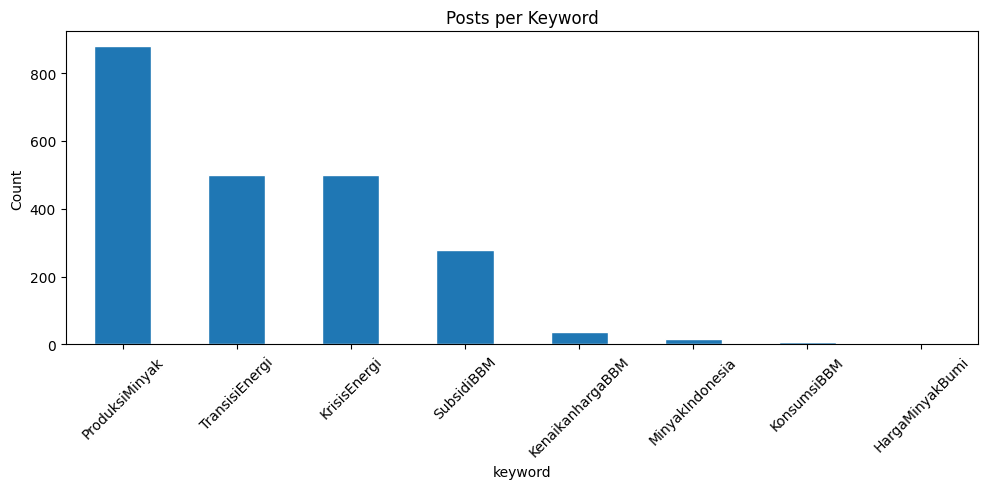


✅ Saved to output\eda_keywords.png

Users posting on multiple keywords (potential bridge nodes): 218
username
350id              3
advokasinegeri     3
aktifmimpi         3
aktual.darurat     3
awasfenomena       3
asikcahaya         3
bedahkejadian      3
berdayajaya        3
cepatperistiwa     3
inovatifwarna      3
gerakmantap        3
hecktor.03         3
indo.flashid       3
investordailyid    3
kapitalismarket    3
jurnallangkah      3
energikkarya       3
dagangunggul       3
cuplikanpekan      3
cermatkabar        3
Name: keyword, dtype: int64


In [ ]:
# ── Keyword Distribution ──────────────────────────────────────────────────────

import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

if "keyword" in df.columns:

    # Handle missing values safely
    kw_counts = (
        df["keyword"]
        .fillna("unknown")
        .astype(str)
        .value_counts()
    )

    print(f"Unique keywords: {len(kw_counts):,}")

    print("\nKeyword distribution:")
    print(kw_counts.to_string())

    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))

    kw_counts.head(20).plot(
        kind="bar",
        ax=ax,
        edgecolor="white"
    )

    ax.set_title("Posts per Keyword")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()

    # ── SAFE SAVE ─────────────────────────

    output_dir = Path("output")
    output_dir.mkdir(exist_ok=True)

    file_path = output_dir / "eda_keywords.png"

    plt.savefig(
        file_path,
        bbox_inches="tight"
    )

    plt.show()

    print(f"\n✅ Saved to {file_path}")

    # ── Bridge Node Detection (SNA insight)

    user_kw = (
        df
        .groupby("username")["keyword"]
        .nunique()
    )

    multi_kw_users = user_kw[user_kw > 1]

    print(
        f"\nUsers posting on multiple keywords "
        f"(potential bridge nodes): {len(multi_kw_users):,}"
    )

    print(
        multi_kw_users
        .sort_values(ascending=False)
        .head(20)
    )

##### Network Feasibility Estimation

In [ ]:
# ── Network Feasibility Summary ───────────────────────────────────────────────

print("=" * 60)
print("NETWORK FEASIBILITY REPORT")
print("=" * 60)

# ── Method 1: Mention-based edges

if "edges_df" in globals() and len(edges_df) > 0:

    n_mention_edges = edges_df[["source","target"]].drop_duplicates().shape[0]

else:

    n_mention_edges = 0

print(f"\n[Method 1] Mention-Based Edges: {n_mention_edges:,}")

if n_mention_edges > 0:

    mentioned_users_in_dataset = (
        set(edges_df["target"])
        .intersection(set(df["username"]))
    )

    print(
        f"  Targets found in dataset: "
        f"{len(mentioned_users_in_dataset):,}"
    )

    print(
        f"  External targets (not in dataset): "
        f"{len(set(edges_df['target'])) - len(mentioned_users_in_dataset):,}"
    )

# ── Method 2: Co-keyword edges

if "keyword" in df.columns:

    kw_groups = (
        df
        .groupby("keyword")["username"]
        .nunique()
    )

    potential_kw_edges = sum(
        n * (n - 1) // 2
        for n in kw_groups
    )

    print(
        f"\n[Method 2] Co-Keyword Potential Edges: "
        f"{potential_kw_edges:,}"
    )

    print(
        "  (estimated, before time-windowing)"
    )

# ── Method 3: Hashtag co-occurrence

if "n_hashtags" in df.columns:

    posts_with_hashtags = (
        (df["n_hashtags"] > 0)
        .sum()
    )

else:

    posts_with_hashtags = 0

if "hashtags" in df.columns:

    unique_hashtags = len(hashtag_counter)

else:

    unique_hashtags = 0

print("\n[Method 3] Hashtag Co-occurrence:")

print(
    f"  Posts with hashtags: "
    f"{posts_with_hashtags:,}"
)

print(
    f"  Unique hashtags    : "
    f"{unique_hashtags:,}"
)

# ── Nodes

print("\n" + "=" * 60)

print("NODES")

print(
    f"  Total unique usernames  : "
    f"{df['username'].nunique():,}"
)

# ── Strategy recommendation

print("\nRECOMMENDED EDGE STRATEGY:")

if n_mention_edges > df["username"].nunique():

    print("  ✅ Mention edges are sufficient for primary SNA")

    print(
        "  ➕ Supplement with co-keyword edges for denser graph"
    )

else:

    print("  ⚠️  Mention edges are sparse (<100)")

    print(
        "  → PRIMARY: Use co-keyword + co-hashtag edges"
    )

    print(
        "  → WEIGHT edges by interaction score"
    )

print("=" * 60)

NETWORK FEASIBILITY REPORT

[Method 1] Mention-Based Edges: 99
  Targets found in dataset: 11
  External targets (not in dataset): 67

[Method 2] Co-Keyword Potential Edges: 528,374
  (estimated, before time-windowing)

[Method 3] Hashtag Co-occurrence:
  Posts with hashtags: 1,278
  Unique hashtags    : 1,609

NODES
  Total unique usernames  : 1,642

RECOMMENDED EDGE STRATEGY:
  ⚠️  Mention edges are sparse (<100)
  → PRIMARY: Use co-keyword + co-hashtag edges
  → WEIGHT edges by interaction score


##### Analisis:
- di method 2, ada 528,374 potential edge,a artinya: kalau semua user dengan keyword yang sama, di-connect satu sama lain, akan ada 528,374 pasangan user (belum filtering)
- req SNA => nodes = edge OR nodes < edge 

### SNA 

In [ ]:
# ── Configuration ──────────────────────────────────────────────────────────────
# Ganti sesuai kondisi data (lihat hasil EDA)
USE_MENTION_EDGES   = True   # Set False jika mention edges < 50
USE_COKW_EDGES      = True   # Co-keyword edges
MIN_EDGE_WEIGHT     = 2      # Filter edges di bawah threshold ini
MIN_NODE_POSTS      = 1      # Filter users dengan post < threshold
TOP_N_NODES         = 100    # Limit untuk visualisasi (supaya tidak overloaded)

print('Config set ✅')

Config set ✅


## Build mentioned-network edges

In [ ]:
import ast

df["mentions"] = df["mentions"].apply(
    lambda x: ast.literal_eval(x)
    if isinstance(x, str)
    else x
)

In [ ]:
df_mentions = df[
    df["n_mentions"] > 0
].copy()

In [ ]:
df_mentions = df_mentions.explode(
    "mentions"
)

In [ ]:
edges_df = df_mentions.rename(
    columns={
        "username": "source",
        "mentions": "target"
    }
)

In [ ]:
edges_df["source"] = (
    edges_df["source"]
    .str.lower()
    .str.strip()
)

edges_df["target"] = (
    edges_df["target"]
    .str.lower()
    .str.strip()
    .str.replace("@", "", regex=False)
)

In [ ]:
edges_df = edges_df[
    edges_df["source"]
    != edges_df["target"]
]

In [ ]:
edges_df = (
    edges_df
    .groupby(
        ["source", "target"]
    )
    .agg(
        weight=(
            "target",
            "count"
        ),

        n_posts=(
            "post_id",
            "nunique"
        ),

        n_comments=(
            "comment_id",
            "nunique"
        )
    )
    .reset_index()
)

In [ ]:
print("Total edges:", len(edges_df))

print(
    edges_df["weight"].describe()
)

Total edges: 99
count    99.000000
mean      1.070707
std       0.327406
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       3.000000
Name: weight, dtype: float64


In [ ]:
import networkx as nx

G_mention = nx.from_pandas_edgelist(
    edges_df,
    source="source",
    target="target",
    edge_attr="weight",
    create_using=nx.DiGraph()
)

print(
    "Nodes:",
    G_mention.number_of_nodes()
)

print(
    "Edges:",
    G_mention.number_of_edges()
)

Nodes: 134
Edges: 99


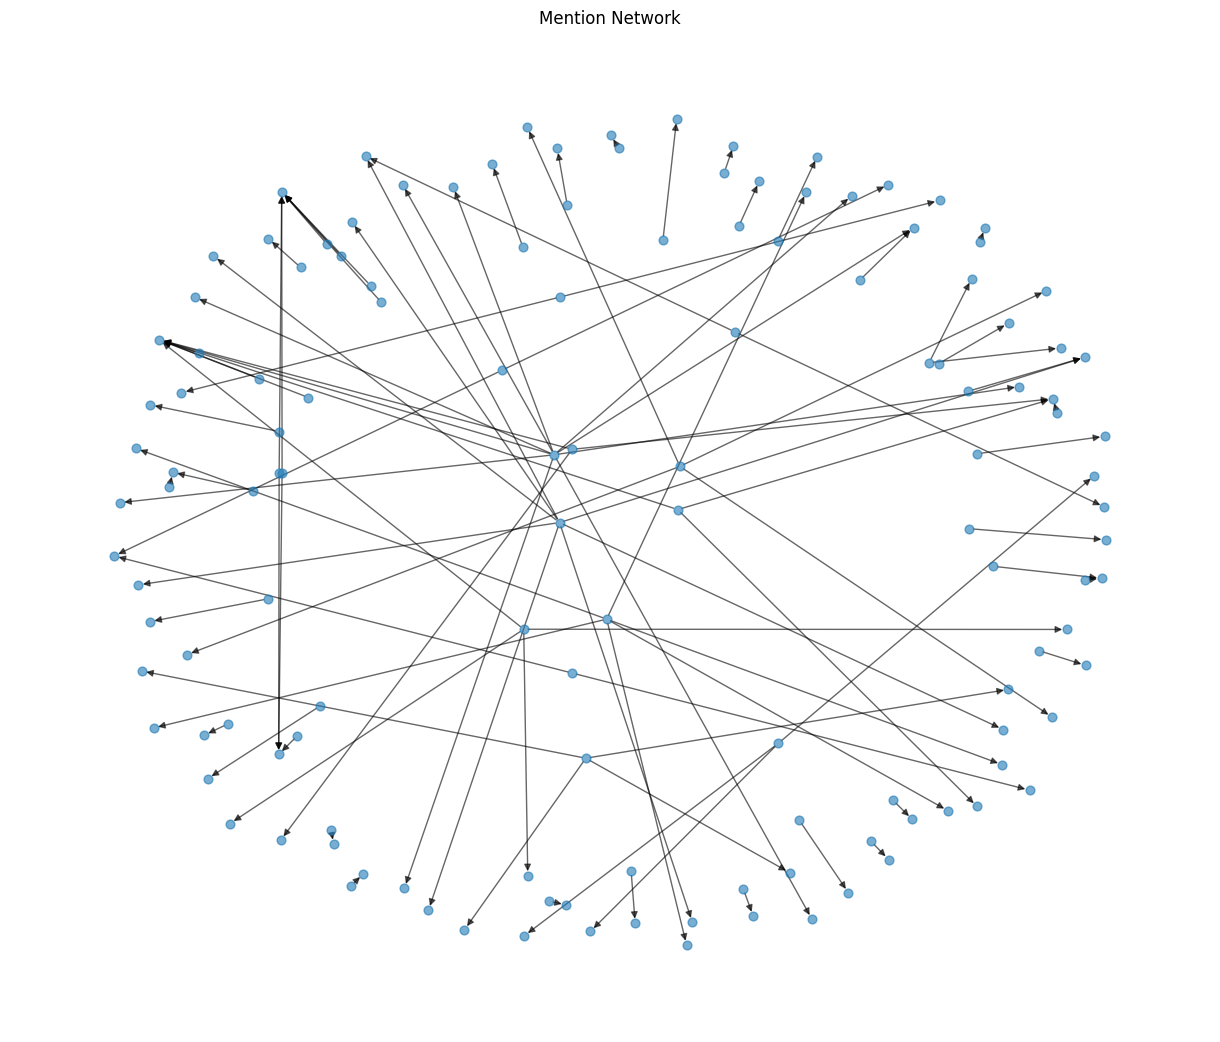

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

pos = nx.spring_layout(
    G_mention,
    seed=42
)

nx.draw(
    G_mention,
    pos,
    node_size=40,
    alpha=0.6,
    arrows=True
)

plt.title("Mention Network")

plt.axis("off")

plt.show()

# Build co-keyword + co-hashtag edges

In [ ]:
# convert date to  datetime
df["date"] = pd.to_datetime(df["date"])

##### build co-keyword edges

In [ ]:
'''
ex output:
userA dan userB muncul bersama dalam keyword yang sama sebanyak 3 kali
'''
from itertools import combinations
from collections import Counter
import pandas as pd

# ── Group users by keyword

kw_groups = (
    df
    .groupby("keyword")["username"]
    .apply(lambda x: list(set(x)))
)

edge_counter = Counter()

# ── Generate user pairs

for users in kw_groups:

    if len(users) < 2:
        continue

    for pair in combinations(users, 2):

        pair = tuple(sorted(pair))

        edge_counter[pair] += 1

# ── Convert to DataFrame

co_keyword_edges = pd.DataFrame(
    [
        {
            "source": u,
            "target": v,
            "weight": w
        }
        for (u, v), w in edge_counter.items()
    ]
)

print("Co-keyword edges:", len(co_keyword_edges))
co_keyword_edges.head()

Co-keyword edges: 509516


,source,target,weight
0,herrywisanggeni,madiuntoday.id,1
1,ana_nopriy,madiuntoday.id,1
2,bantenraya,madiuntoday.id,1
3,madiuntoday.id,rri_bone,1
4,madiuntoday.id,murianewscom,1


##### Analisis:
- Ada 509.516 pasangan user unik yang pernah memakai keyword yang sama minimal 1 kali, artinya bisa post / comment
- 509.516 = unique user pairs


In [ ]:
n_nodes = len(
    set(co_keyword_edges["source"])
    | set(co_keyword_edges["target"])
)

co_keyword_edges["weight"].mean()
co_keyword_edges["weight"].max()
co_keyword_edges["weight"].describe()

count    509516.000000
mean          1.037012
std           0.199712
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           3.000000
Name: weight, dtype: float64

In [ ]:
import networkx as nx

G = nx.from_pandas_edgelist(
    co_keyword_edges,
    "source",
    "target",
    edge_attr="weight"
)

nx.density(G)

0.3786477608834589

##### Analisis:
- density = 0.75 (2E(jumlah edges)/N(N-1)(jumlah nodes(user)))
- 75% dari semua user saling terhubung satu sama lain
- RED FLAG, karena keywordnya masih terlalu umum

##### Tambahkan time-window: hanya connect jika dalam 7 hari

In [ ]:
# using time-windowed co-occurrence

TIME_WINDOW_DAYS = 7
edge_counter = Counter()

for keyword, group in df.groupby("keyword"):
    group = group.sort_values("date")
    records = group[["username", "date"]].drop_duplicates()

    for i in range(len(records)):
        u1 = records.iloc[i]

        for j in range(i + 1, len(records)):
            u2 = records.iloc[j]
            diff = abs(
                (u2["date"] - u1["date"]).days
            )

            if diff > TIME_WINDOW_DAYS:
                break

            pair = tuple(sorted([
                u1["username"],
                u2["username"]
            ]))

            edge_counter[pair] += 1

In [ ]:
# hanya simpan relasi yg min. muncul 2x
MIN_WEIGHT = 2

co_keyword_edges = co_keyword_edges[
    co_keyword_edges["weight"] >= MIN_WEIGHT
]

In [ ]:
pair_interaction = (
    df
    .groupby(["keyword", "username"])["total_interaction"]
    .sum()
    .reset_index()
)

In [ ]:
# build networkx graph

import networkx as nx

G_kw = nx.from_pandas_edgelist(
    co_keyword_edges,
    source="source",
    target="target",
    edge_attr="weight"
)

print("Nodes:", G_kw.number_of_nodes())
print("Edges:", G_kw.number_of_edges())

Nodes: 218
Edges: 17777


##### Analisis
- density masih tinggi (0.75)

In [ ]:
df.groupby("keyword")["username"] \
  .nunique() \
  .sort_values(ascending=False) \
  .head(10)

keyword
ProduksiMinyak      820
TransisiEnergi      414
KrisisEnergi        399
SubsidiBBM          234
KenaikanhargaBBM     26
MinyakIndonesia      14
KonsumsiBBM           6
HargaMinyakBumi       1
Name: username, dtype: int64

##### Analisis
- giant overlapping communities
- secara SNA, ini kurang informatif kalau tidak difilter

In [ ]:
degree = nx.degree_centrality(G_kw)

betweenness = nx.betweenness_centrality(
    G_kw,
    weight="weight"
)

eigenvector = nx.eigenvector_centrality(
    G_kw,
    weight="weight",
    max_iter=1000
)

In [ ]:
df_hashtag = df.copy()

df_hashtag = df_hashtag.explode("hashtags")

df_hashtag = df_hashtag[
    df_hashtag["hashtags"].notna()
]

In [ ]:
from itertools import combinations
from collections import Counter

edge_counter_ht = Counter()

for hashtag, group in df_hashtag.groupby("hashtags"):
    users = list(set(group["username"]))

    if len(users) < 2:
        continue

    for pair in combinations(users, 2):
        pair = tuple(sorted(pair))
        edge_counter_ht[pair] += 1


co_hashtag_edges = pd.DataFrame(
    [
        {
            "source": u,
            "target": v,
            "weight": w
        }
        for (u, v), w in edge_counter_ht.items()
    ]
)

print("Co-hashtag edges:", len(co_hashtag_edges))

Co-hashtag edges: 190060


In [ ]:
combined_edges = pd.concat(
    [
        co_keyword_edges,
        co_hashtag_edges
    ],
    ignore_index=True
)

combined_edges = (
    combined_edges
    .groupby(["source", "target"])["weight"]
    .sum()
    .reset_index()
)

print("Combined edges:", len(combined_edges))

Combined edges: 190060


In [ ]:
print(len(co_keyword_edges))
print(len(co_hashtag_edges))

17777
190060


In [ ]:
kw_pairs = set(
    zip(
        co_keyword_edges["source"],
        co_keyword_edges["target"]
    )
)

ht_pairs = set(
    zip(
        co_hashtag_edges["source"],
        co_hashtag_edges["target"]
    )
)

overlap = kw_pairs & ht_pairs

print("Overlap:", len(overlap))
print("Keyword:", len(kw_pairs))
print("Hashtag:", len(ht_pairs))

Overlap: 17777
Keyword: 17777
Hashtag: 190060


In [ ]:
print(G.number_of_edges())
print(len(combined_edges))

509516
190060


In [ ]:
import networkx as nx

G = nx.from_pandas_edgelist(
    combined_edges,
    source="source",
    target="target",
    edge_attr="weight"
)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 837
Edges: 190060


In [ ]:
density = nx.density(G)

print("Network density:", round(density, 4))

Network density: 0.5432


In [ ]:
!pip install python-louvain


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import community as community_louvain

partition = community_louvain.best_partition(
    G,
    weight="weight"
)

nx.set_node_attributes(
    G,
    partition,
    "community"
)

print(
    "Number of communities:",
    len(set(partition.values()))
)

Number of communities: 4


In [ ]:
degree = nx.degree_centrality(G)

betweenness = nx.betweenness_centrality(
    G,
    weight="weight"
)

eigenvector = nx.eigenvector_centrality(
    G,
    weight="weight",
    max_iter=1000
)

In [ ]:
centrality_df = pd.DataFrame({

    "username": list(degree.keys()),

    "degree":

        list(degree.values()),

    "betweenness":

        list(betweenness.values()),

    "eigenvector":

        list(eigenvector.values())

})

centrality_df = centrality_df.sort_values(
    "eigenvector",
    ascending=False
)

centrality_df.head(10)

,username,degree,betweenness,eigenvector
29,aktual.darurat,0.954545,0.001254,0.079245
404,lembaranpetualangan,0.949761,0.001533,0.079141
647,setiaberdaulat,0.952153,0.001549,0.078130
660,sipilberkeadilan,0.954545,0.000969,0.077320
366,kilattindakan,0.956938,0.001550,0.076874
161,cuplikanpekan,0.952153,0.001569,0.076200
291,indo.flashid,0.949761,0.001503,0.076046
588,rangkaisederhana,0.952153,0.001224,0.075795
402,lembahelok,0.952153,0.001534,0.075771
28,aktifmimpi,0.949761,0.001504,0.075294


In [ ]:
centrality_df["community"] = (
    centrality_df["username"]
    .map(partition)
)

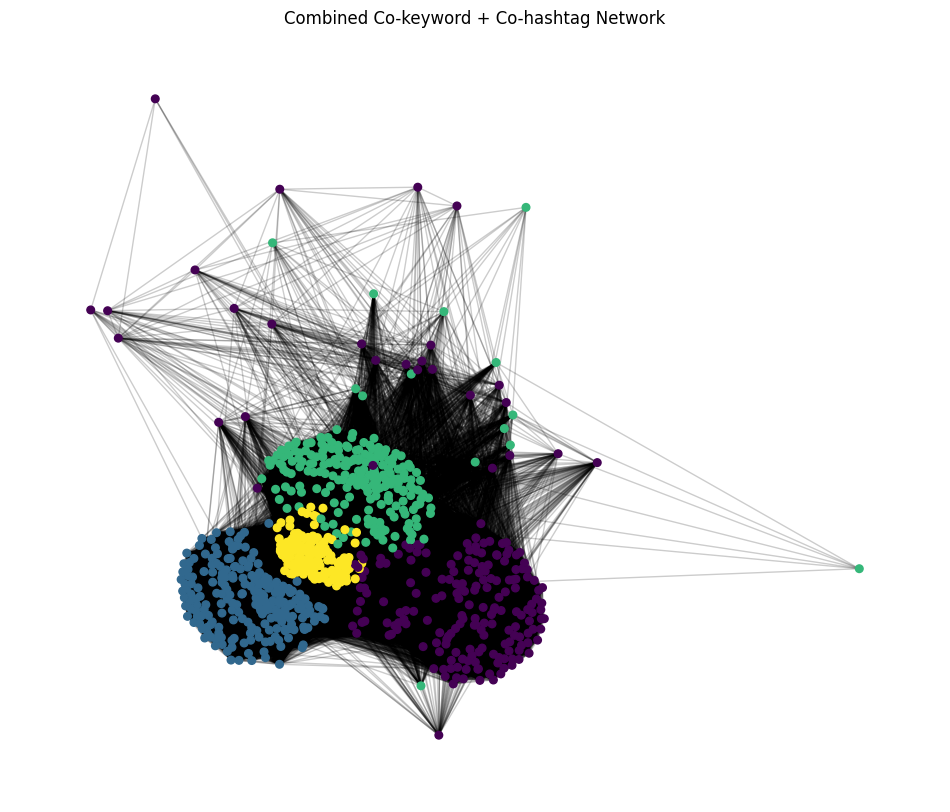

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

pos = nx.spring_layout(
    G,
    k=0.15,
    seed=42
)

communities = nx.get_node_attributes(
    G,
    "community"
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=30,
    node_color=list(communities.values())
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.2
)

plt.title("Combined Co-keyword + Co-hashtag Network")

plt.axis("off")

plt.show()

#### Ganti Arsitektur
- using co-hashtag
- weight = jumlah hashtag yg sama
- attribute: keyword, sentiment, total_interaction, is_comment

In [ ]:
G = nx.from_pandas_edgelist(
    co_hashtag_edges,
    source="source",
    target="target",
    edge_attr="weight"
)

In [ ]:
keyword_map = (
    df
    .groupby("username")["keyword"]
    .agg(lambda x: list(set(x)))
    .to_dict()
)

nx.set_node_attributes(
    G,
    keyword_map,
    "keywords"
)

In [ ]:
import pandas as pd

node_attributes = (
    df
    .groupby("username")
    .agg(
        dominant_sentiment = (
            "sentiment_label",
            lambda x: x.mode()[0]
        ),

        total_interaction = (
            "total_interaction",
            "sum"
        ),

        comment_ratio = (
            "is_comment",
            "mean"
        ),

        active_hour = (
            "hour",
            lambda x: x.mode()[0]
        ),

        active_period = (
            "year_month",
            lambda x: x.mode()[0]
        )
    )
    .reset_index()
)

node_attributes.head()

,username,dominant_sentiment,total_interaction,comment_ratio,active_hour,active_period
0,0h_gituh,Neutral,0,1.0,11,2026-04
1,350id,Positive,0,0.0,14,2026-04
2,4_1fulll,Positive,0,0.0,2,2026-04
3,4erielle,Positive,0,1.0,4,2026-04
4,4l3x42022,Neutral,0,1.0,14,2026-04


In [ ]:
node_attr_dict = (
    node_attributes
    .set_index("username")
    .to_dict(orient="index")
)

In [ ]:
import networkx as nx

nx.set_node_attributes(
    G,
    node_attr_dict
)

In [ ]:
sample_node = list(G.nodes())[0]

G.nodes[sample_node]

{'keywords': ['KrisisEnergi'],
 'dominant_sentiment': 'Negative',
 'total_interaction': 0,
 'comment_ratio': 0.0,
 'active_hour': 0,
 'active_period': Period('2026-04', 'M')}

In [ ]:
keyword_map = (
    df
    .groupby("username")["keyword"]
    .agg(lambda x: list(set(x)))
    .to_dict()
)

nx.set_node_attributes(
    G,
    keyword_map,
    "keywords"
)

In [ ]:
extra_attr = (
    df
    .groupby("username")
    .agg(
        total_mentions = (
            "n_mentions",
            "sum"
        ),

        total_hashtags = (
            "n_hashtags",
            "sum"
        )
    )
    .to_dict(orient="index")
)

nx.set_node_attributes(
    G,
    extra_attr
)

In [ ]:
MIN_WEIGHT = 2

co_hashtag_edges = co_hashtag_edges[
    co_hashtag_edges["weight"] >= MIN_WEIGHT
]

In [ ]:
sample_node = list(G.nodes())[0]

G.nodes[sample_node]

{'keywords': ['KrisisEnergi'],
 'dominant_sentiment': 'Negative',
 'total_interaction': 0,
 'comment_ratio': 0.0,
 'active_hour': 0,
 'active_period': Period('2026-04', 'M'),
 'total_mentions': 0,
 'total_hashtags': 11}

In [ ]:
node_attr_df = pd.DataFrame.from_dict(
    dict(G.nodes(data=True)),
    orient="index"
)

node_attr_df = (
    node_attr_df
    .reset_index()
    .rename(columns={
        "index": "username"
    })
)

node_attr_df.head()

,username,keywords,dominant_sentiment,total_interaction,comment_ratio,active_hour,active_period,total_mentions,total_hashtags
0,borobudur_news,[KrisisEnergi],Negative,0,0.0,0,2026-04,0,11
1,infobank_official,[SubsidiBBM],Neutral,0,0.0,5,2026-04,0,8
2,akademi.antikorupsi,[TransisiEnergi],Neutral,0,0.0,4,2026-04,0,12
3,gracegunawans,[TransisiEnergi],Positive,0,0.0,15,2026-04,1,3
4,mumpuniintimandiri,[TransisiEnergi],Positive,0,0.0,7,2026-04,0,19


In [ ]:
centrality_df = centrality_df.merge(
    node_attr_df,
    on="username",
    how="left"
)

In [ ]:
centrality_df.groupby("community")[
    "dominant_sentiment"
].value_counts()

community  dominant_sentiment
0          Positive              113
           Neutral                68
           Negative               31
1          Positive              157
           Neutral                57
           Negative               11
2          Negative               95
           Neutral                89
           Positive               34
3          Positive              176
           Negative                3
           Neutral                 3
Name: count, dtype: int64

In [ ]:
(
    centrality_df
    .groupby("community")["dominant_sentiment"]
    .value_counts(normalize=True)
    .round(3)
)

community  dominant_sentiment
0          Positive              0.533
           Neutral               0.321
           Negative              0.146
1          Positive              0.698
           Neutral               0.253
           Negative              0.049
2          Negative              0.436
           Neutral               0.408
           Positive              0.156
3          Positive              0.967
           Negative              0.016
           Neutral               0.016
Name: proportion, dtype: float64

In [ ]:
centrality_df.sort_values(
    "eigenvector",
    ascending=False
).groupby("community").head(5)

,username,degree,betweenness,eigenvector,community,keywords,dominant_sentiment,total_interaction,comment_ratio,active_hour,active_period,total_mentions,total_hashtags
0,aktual.darurat,0.954545,0.001254,0.079245,3,"[SubsidiBBM, KrisisEnergi, TransisiEnergi]",Positive,0,0.0,4,2026-04,0,28
1,lembaranpetualangan,0.949761,0.001533,0.079141,3,"[SubsidiBBM, KrisisEnergi, TransisiEnergi]",Positive,0,0.0,4,2026-04,0,30
2,setiaberdaulat,0.952153,0.001549,0.078130,3,"[SubsidiBBM, KrisisEnergi, TransisiEnergi]",Positive,0,0.0,4,2026-04,0,26
3,sipilberkeadilan,0.954545,0.000969,0.077320,3,"[SubsidiBBM, KrisisEnergi, TransisiEnergi]",Positive,0,0.0,4,2026-04,0,26
4,kilattindakan,0.956938,0.001550,0.076874,3,"[SubsidiBBM, KrisisEnergi, TransisiEnergi]",Positive,0,0.0,4,2026-04,0,30
102,kupaslapangan,0.971292,0.001614,0.067752,0,"[SubsidiBBM, KrisisEnergi, TransisiEnergi]",Positive,0,0.0,4,2026-04,0,37
167,kapitalismarket,0.966507,0.001801,0.047305,0,"[SubsidiBBM, KrisisEnergi, TransisiEnergi]",Neutral,0,0.0,6,2026-04,0,30
168,gagahmakmur,0.544258,0.000058,0.044348,1,[TransisiEnergi],Positive,0,0.0,17,2026-04,0,10
169,tanggapagenda,0.545455,0.000061,0.044171,1,[TransisiEnergi],Positive,0,0.0,17,2026-04,0,10
170,validnews,0.854067,0.001093,0.043654,2,"[KrisisEnergi, TransisiEnergi]",Neutral,0,0.0,8,2026-04,4,25


In [ ]:
centrality_df.sort_values(
    "total_interaction",
    ascending=False
).head(10)

,username,degree,betweenness,eigenvector,community,keywords,dominant_sentiment,total_interaction,comment_ratio,active_hour,active_period,total_mentions,total_hashtags
807,otoproject,0.169856,0.001125,0.000900,2,"[ProduksiMinyak, KenaikanhargaBBM]",Neutral,3,0.125,4,2026-03,0,38
818,meka007,0.100478,0.000057,0.000456,0,[ProduksiMinyak],Neutral,3,1.000,4,2026-03,1,16
20,inovatifwarna,0.954545,0.001717,0.073564,3,"[SubsidiBBM, KrisisEnergi, TransisiEnergi]",Positive,0,0.000,4,2026-04,0,26
821,otospector,0.082536,0.000209,0.000387,0,[KenaikanhargaBBM],Neutral,0,0.000,11,2026-03,0,4
820,suaradotcom,0.084928,0.000215,0.000399,0,[KenaikanhargaBBM],Neutral,0,0.000,12,2026-04,0,3
2,setiaberdaulat,0.952153,0.001549,0.078130,3,"[SubsidiBBM, KrisisEnergi, TransisiEnergi]",Positive,0,0.000,4,2026-04,0,26
6,indo.flashid,0.949761,0.001503,0.076046,3,"[SubsidiBBM, KrisisEnergi, TransisiEnergi]",Positive,0,0.000,9,2026-04,0,25
7,rangkaisederhana,0.952153,0.001224,0.075795,3,"[SubsidiBBM, KrisisEnergi, TransisiEnergi]",Positive,0,0.000,4,2026-04,0,25
8,lembahelok,0.952153,0.001534,0.075771,3,"[SubsidiBBM, KrisisEnergi, TransisiEnergi]",Positive,0,0.000,4,2026-04,0,23
9,aktifmimpi,0.949761,0.001504,0.075294,3,"[SubsidiBBM, KrisisEnergi, TransisiEnergi]",Positive,0,0.000,4,2026-04,0,23


In [ ]:
centrality_df[
    centrality_df["comment_ratio"] > 0.8
]

,username,degree,betweenness,eigenvector,community,keywords,dominant_sentiment,total_interaction,comment_ratio,active_hour,active_period,total_mentions,total_hashtags
818,meka007,0.100478,0.000057,0.000456,0,[ProduksiMinyak],Neutral,3,1.0,4,2026-03,1,16


In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

In [ ]:
!pip install fa2


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


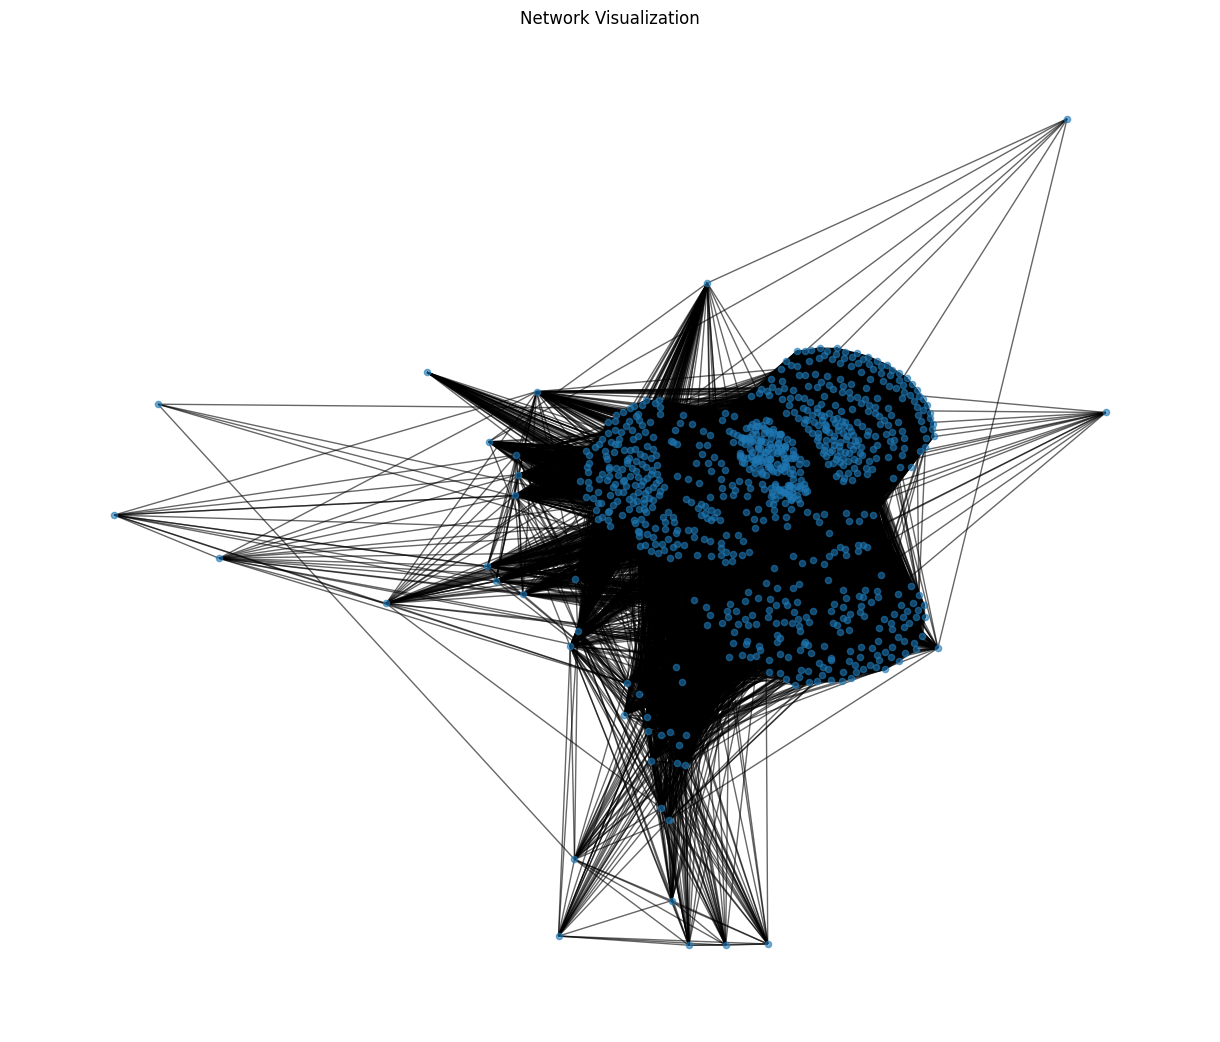

In [ ]:
plt.figure(figsize=(12, 10))

pos = nx.spring_layout(
    G,
    seed=42
)

nx.draw(
    G,
    pos,
    node_size=20,
    alpha=0.6
)

plt.title("Network Visualization")

plt.axis("off")

plt.show()

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\networkx\drawing\nx_pylab.py:1497: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


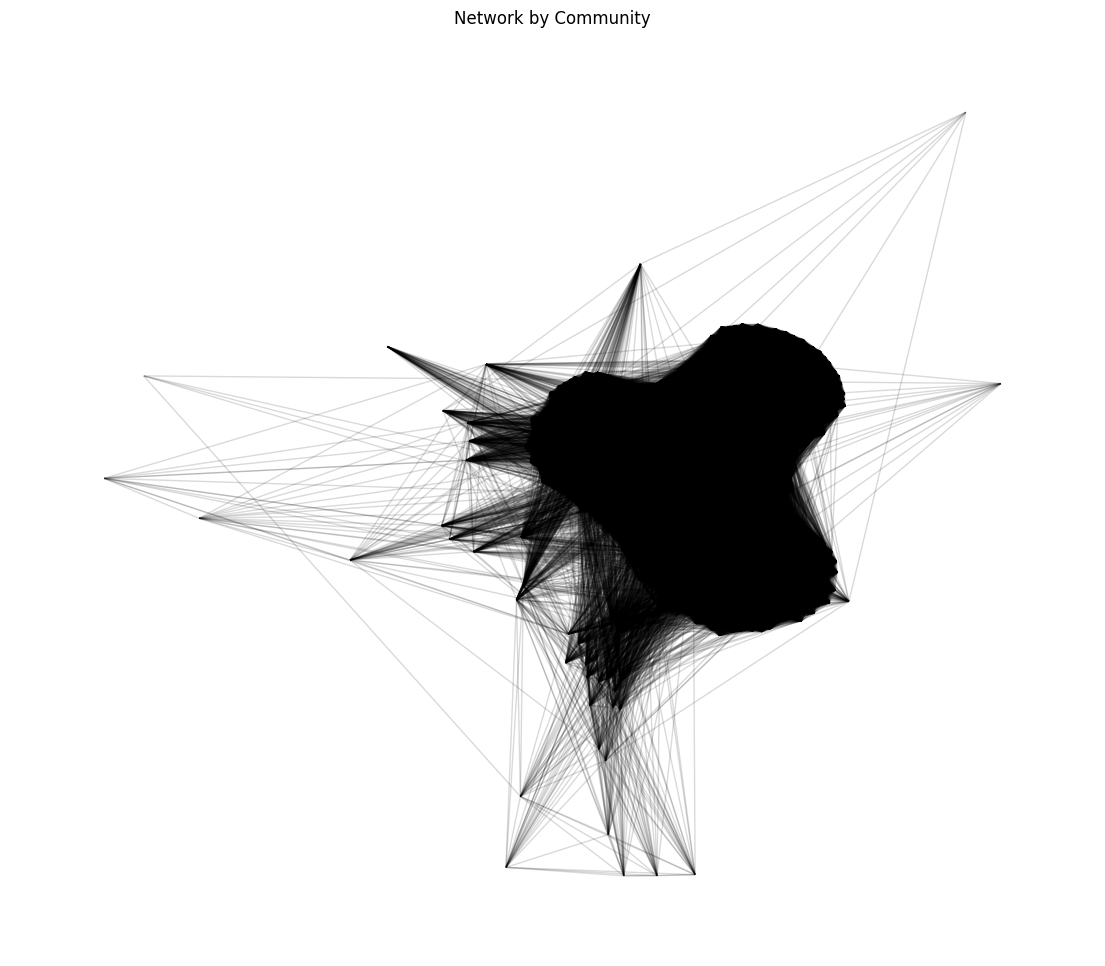

In [ ]:
plt.figure(figsize=(14, 12))

pos = nx.spring_layout(
    G,
    seed=42
)

communities = nx.get_node_attributes(
    G,
    "community"
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=30,
    node_color=list(communities.values()),
    cmap=plt.cm.tab20
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.15
)

plt.title("Network by Community")

plt.axis("off")

plt.show()

In [ ]:
top_users = (
    centrality_df
    .sort_values(
        "eigenvector",
        ascending=False
    )
    .head(10)
)["username"]

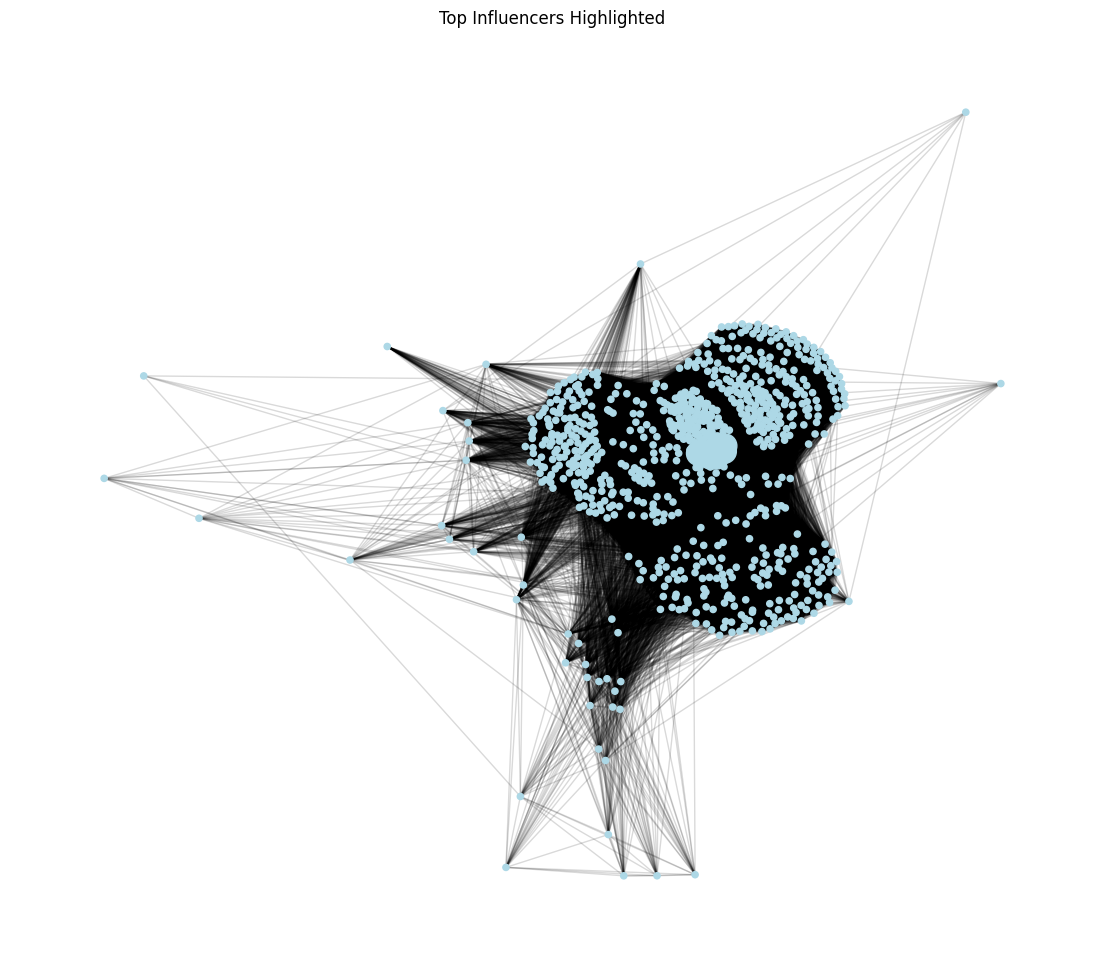

In [ ]:
plt.figure(figsize=(14, 12))

pos = nx.spring_layout(
    G,
    seed=42
)

node_sizes = []

for node in G.nodes():

    if node in top_users.values:

        node_sizes.append(300)

    else:

        node_sizes.append(20)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color="lightblue"
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.15
)

plt.title("Top Influencers Highlighted")

plt.axis("off")

plt.show()

In [ ]:
MIN_WEIGHT = 2

edges_filtered = [
    (u, v, d)
    for u, v, d in G.edges(data=True)
    if d["weight"] >= MIN_WEIGHT
]

G_filtered = nx.Graph()

G_filtered.add_edges_from(edges_filtered)

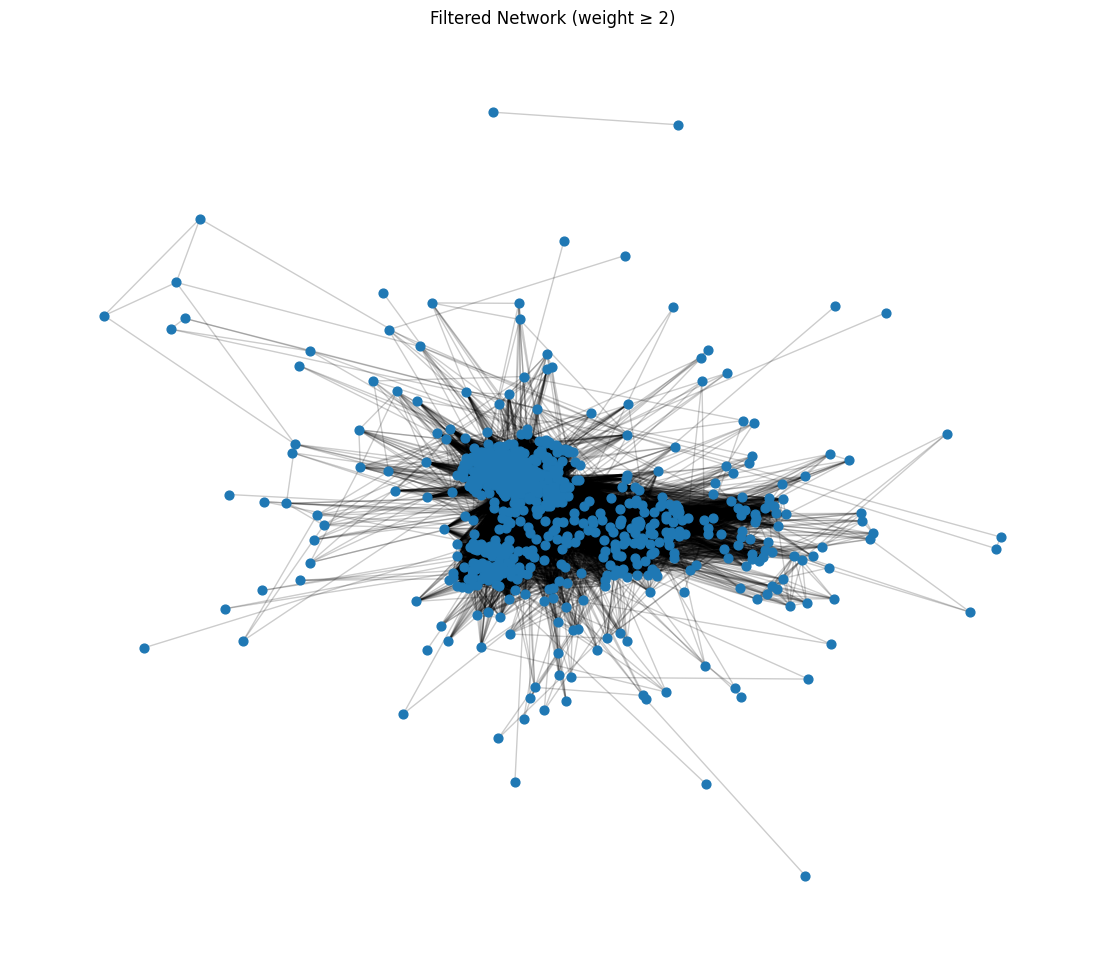

In [ ]:
plt.figure(figsize=(14, 12))

pos = nx.spring_layout(
    G_filtered,
    seed=42
)

nx.draw_networkx_nodes(
    G_filtered,
    pos,
    node_size=40
)

nx.draw_networkx_edges(
    G_filtered,
    pos,
    alpha=0.2
)

plt.title("Filtered Network (weight ≥ 2)")

plt.axis("off")

plt.show()

In [ ]:
community_map = dict(
    zip(
        centrality_df["username"],
        centrality_df["community"]
    )
)

nx.set_node_attributes(
    G,
    community_map,
    "community"
)

In [ ]:
largest_community = (
    centrality_df["community"]
    .value_counts()
    .index[0]
)

nodes_sub = [
    n
    for n in G.nodes()
    if G.nodes[n]["community"] == largest_community
]

G_sub = G.subgraph(nodes_sub)

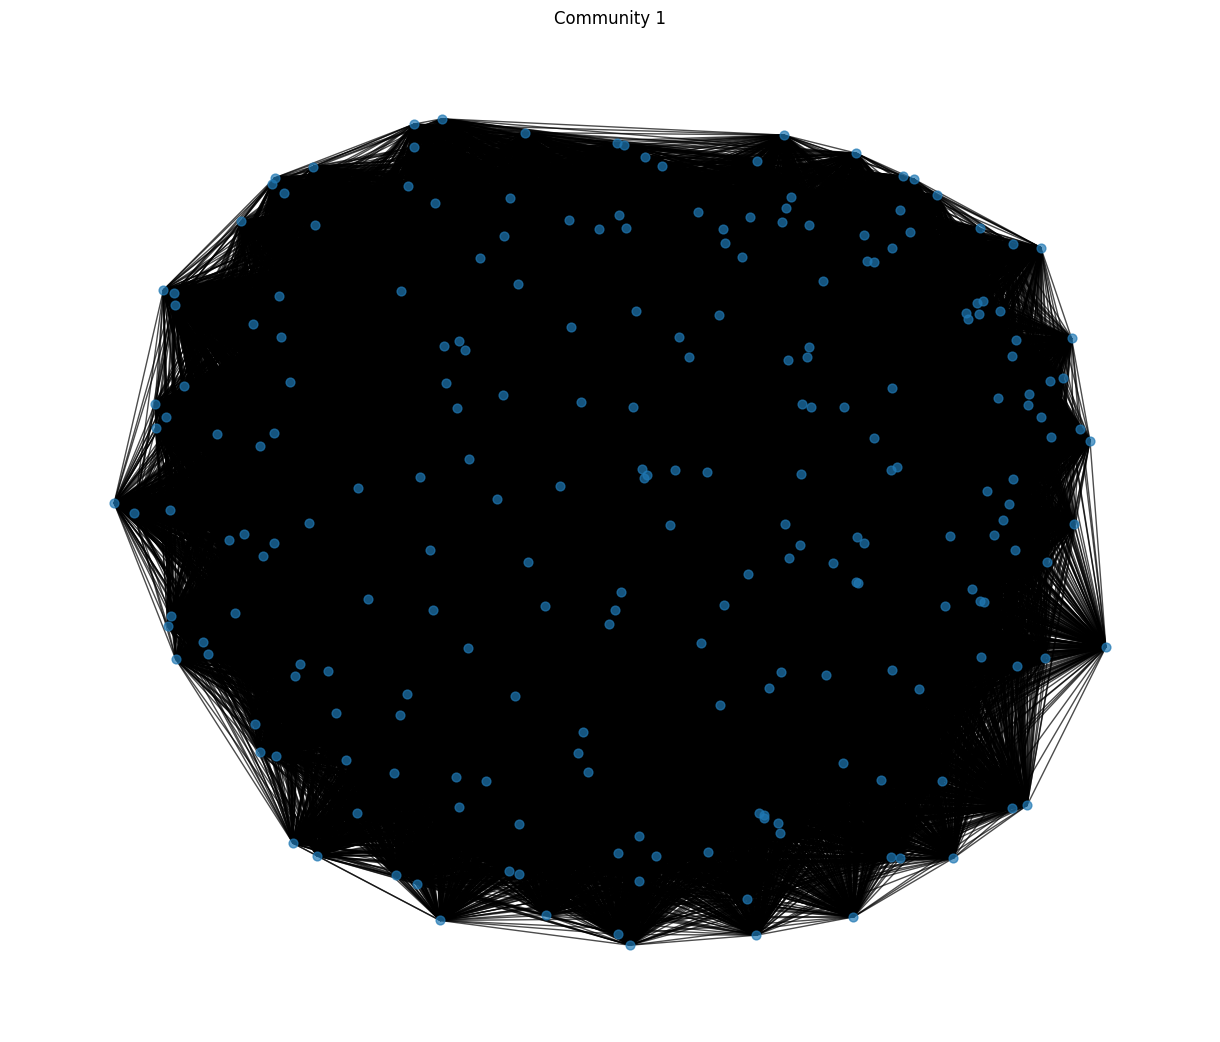

In [ ]:
plt.figure(figsize=(12, 10))

pos = nx.spring_layout(
    G_sub,
    seed=42
)

nx.draw(
    G_sub,
    pos,
    node_size=40,
    alpha=0.7
)

plt.title(
    f"Community {largest_community}"
)

plt.axis("off")

plt.show()

In [ ]:
eigen_dict = dict(
    zip(
        centrality_df["username"],
        centrality_df["eigenvector"]
    )
)

node_sizes = [
    eigen_dict.get(n, 0) * 3000
    for n in G.nodes()
]

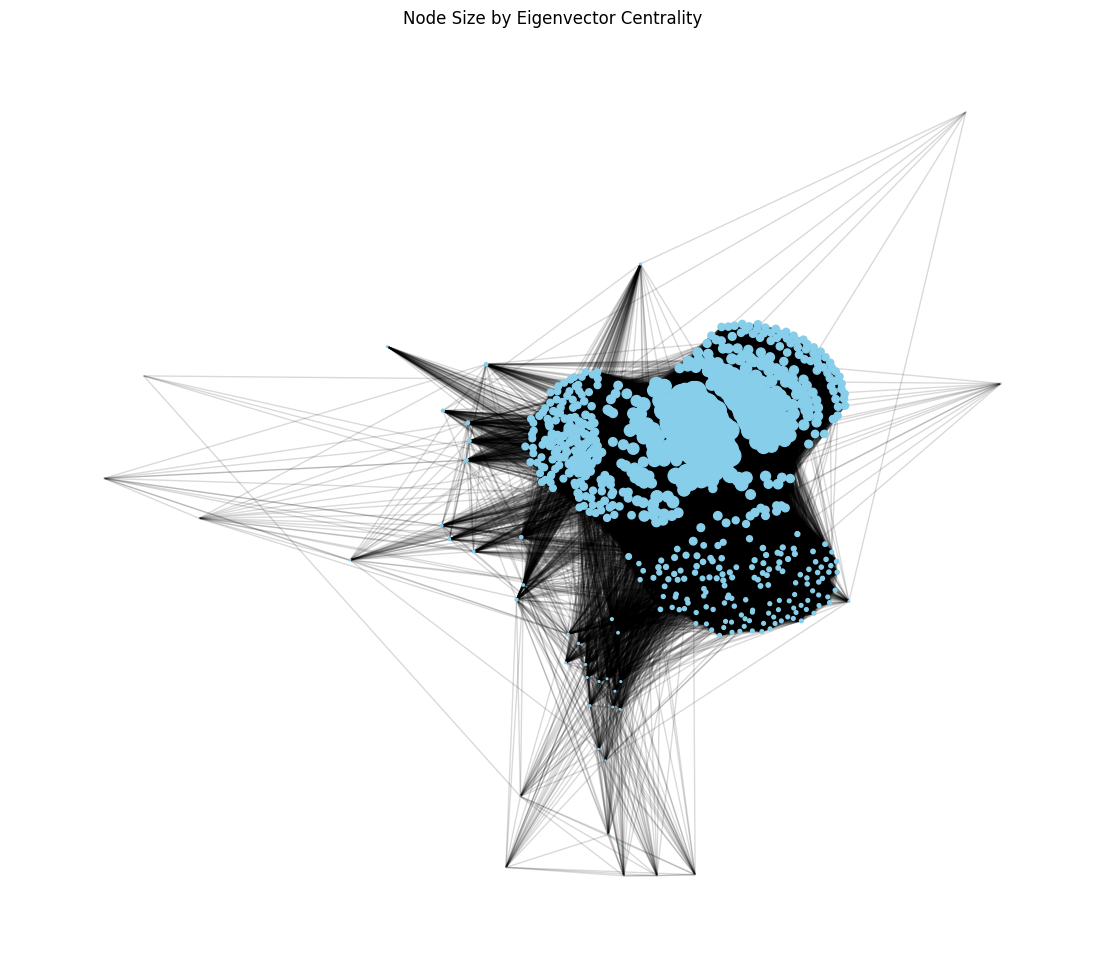

In [ ]:
plt.figure(figsize=(14, 12))

pos = nx.spring_layout(
    G,
    seed=42
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color="skyblue"
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.15
)

plt.title(
    "Node Size by Eigenvector Centrality"
)

plt.axis("off")

plt.show()

### Analisis (Claude)

In [ ]:
print(type(edges_mention))

<class 'list'>


In [ ]:
# ── Combine & Normalize Edges ─────────────────────────────────────────

import pandas as pd

all_edges = []

# --- MENTION EDGES ---

if USE_MENTION_EDGES and len(edges_mention) > 0:

    # Convert list → DataFrame
    if isinstance(edges_mention, list):

        # Handle jika list berisi tuple
        if isinstance(edges_mention[0], tuple):

            edges_mention = pd.DataFrame(
                edges_mention,
                columns=["source", "target"]
            )

        # Handle jika list berisi dict
        else:

            edges_mention = pd.DataFrame(edges_mention)

    em = edges_mention.copy()

    # Ensure weight exists
    if "weight" not in em.columns:
        em["weight"] = 1

    em["edge_type"] = "mention"

    all_edges.append(
        em[["source", "target", "weight", "edge_type"]]
    )


# --- CO-KEYWORD EDGES ---

if USE_COKW_EDGES and len(co_keyword_edges) > 0:

    if isinstance(co_keyword_edges, list):
        co_keyword_edges = pd.DataFrame(co_keyword_edges)

    ek = co_keyword_edges.copy()

    # Normalize / assign weight
    if "co_keyword_count" in ek.columns:
        ek["weight"] = ek["co_keyword_count"]

    elif "weight" not in ek.columns:
        ek["weight"] = 1

    ek["edge_type"] = "co_keyword"

    all_edges.append(
        ek[["source", "target", "weight", "edge_type"]]
    )


# --- CHECK ---

if not all_edges:

    raise ValueError(
        "❌ No edges available! Check EDA output files."
    )


# --- CONCAT ---

edges_combined = pd.concat(
    all_edges,
    ignore_index=True
)


# --- AGGREGATE ---

edges_final = (
    edges_combined
    .groupby(["source", "target"])
    .agg(
        weight=("weight", "sum"),
        edge_types=(
            "edge_type",
            lambda x: "+".join(sorted(set(x)))
        )
    )
    .reset_index()
)


# --- FILTER ---

edges_final = edges_final[
    edges_final["weight"] >= MIN_EDGE_WEIGHT
]


print(f"Final edges: {len(edges_final):,}")

Final edges: 17,782


In [ ]:
# ── Build DiGraph (Directed) ───────────────────────────────────────────────────
G_directed = nx.DiGraph()

# Add nodes with attributes
user_attr = user_metrics.set_index('username').to_dict('index')

for u, attrs in user_attr.items():
    G_directed.add_node(
        u,
        post_count=int(attrs.get('post_count', 0)),
        total_interaction=float(attrs.get('total_interaction', 0) or 0),
        avg_interaction=float(attrs.get('avg_interaction', 0) or 0),
        total_like=float(attrs.get('total_like', 0) or 0),
        total_view=float(attrs.get('total_view', 0) or 0),
    )

# Add edges
for _, row in edges_final.iterrows():
    G_directed.add_edge(
        row['source'], row['target'],
        weight=float(row['weight']),
        edge_type=row['edge_types']
    )

# Also create undirected version for community detection
G_undirected = G_directed.to_undirected()
# Merge parallel edges by summing weight
for u, v, data in G_undirected.edges(data=True):
    if G_directed.has_edge(v, u):
        data['weight'] = data.get('weight', 1) + G_directed[v][u].get('weight', 1)

print(f'Directed graph   — Nodes: {G_directed.number_of_nodes():,}, Edges: {G_directed.number_of_edges():,}')
print(f'Undirected graph — Nodes: {G_undirected.number_of_nodes():,}, Edges: {G_undirected.number_of_edges():,}')

NameError: name 'user_metrics' is not defined

In [ ]:
# ── Network Stats ──────────────────────────────────────────────────────────────
N = G_directed.number_of_nodes()
E = G_directed.number_of_edges()

density = nx.density(G_directed)
avg_degree = E / N if N > 0 else 0

# Connected components (undirected)
components = list(nx.connected_components(G_undirected))
largest_cc = max(components, key=len)
lcc_ratio = len(largest_cc) / N

print('=' * 55)
print('  NETWORK OVERVIEW')
print('=' * 55)
print(f'  Nodes (users)        : {N:,}')
print(f'  Edges (interactions) : {E:,}')
print(f'  Density              : {density:.6f}')
print(f'  Avg degree           : {avg_degree:.2f}')
print(f'  Connected components : {len(components):,}')
print(f'  Largest CC (LCC) size: {len(largest_cc):,} ({lcc_ratio*100:.1f}% of nodes)')
print('=' * 55)

# Degree distribution
in_degrees  = dict(G_directed.in_degree())
out_degrees = dict(G_directed.out_degree())
all_degrees = dict(G_undirected.degree())

print(f'  Avg in-degree  : {np.mean(list(in_degrees.values())):.2f}')
print(f'  Avg out-degree : {np.mean(list(out_degrees.values())):.2f}')
print(f'  Max in-degree  : {max(in_degrees.values())} (most-mentioned)')
print(f'  Max out-degree : {max(out_degrees.values())} (most active mentioner)')

  NETWORK OVERVIEW
  Nodes (users)        : 1,709
  Edges (interactions) : 17,876
  Density              : 0.006124
  Avg degree           : 10.46
  Connected components : 1,395
  Largest CC (LCC) size: 250 (14.6% of nodes)
  Avg in-degree  : 10.46
  Avg out-degree : 10.46
  Max in-degree  : 200 (most-mentioned)
  Max out-degree : 208 (most active mentioner)


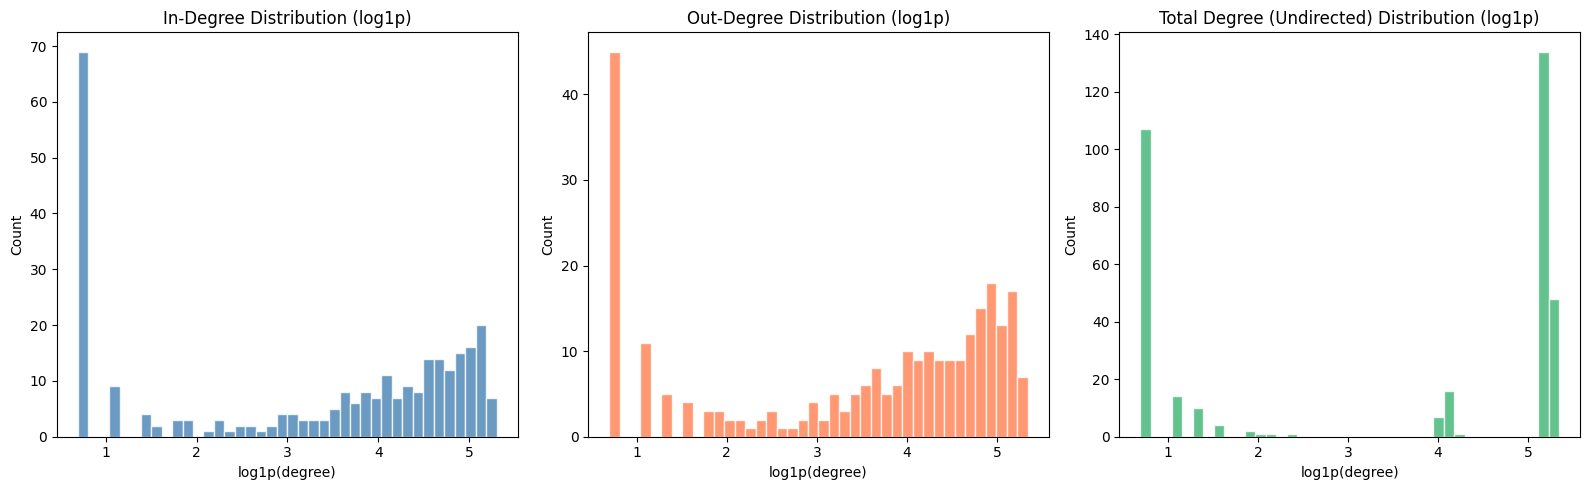

In [ ]:
# ── Degree Distribution Plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, deg_dict, title, color in [
    (axes[0], in_degrees, 'In-Degree', 'steelblue'),
    (axes[1], out_degrees, 'Out-Degree', 'coral'),
    (axes[2], all_degrees, 'Total Degree (Undirected)', 'mediumseagreen')
]:
    vals = list(deg_dict.values())
    vals_nonzero = [v for v in vals if v > 0]
    if vals_nonzero:
        ax.hist(np.log1p(vals_nonzero), bins=40, color=color, edgecolor='white', alpha=0.8)
    ax.set_title(f'{title} Distribution (log1p)')
    ax.set_xlabel('log1p(degree)')
    ax.set_ylabel('Count')

plt.tight_layout()
# plt.savefig('../data/processed/sna_degree_dist.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Compute All Centrality Measures ───────────────────────────────────────────
print('Computing centrality metrics... (may take a moment for large graphs)')

# For large graphs, use LCC subgraph for expensive metrics
G_lcc = G_undirected.subgraph(largest_cc).copy()
G_lcc_dir = G_directed.subgraph(largest_cc).copy()

# 1. Degree Centrality
print('  [1/6] Degree centrality...')
degree_centrality = nx.degree_centrality(G_undirected)
in_degree_centrality = nx.in_degree_centrality(G_directed)
out_degree_centrality = nx.out_degree_centrality(G_directed)

# 2. Betweenness Centrality (expensive, use sample for large graphs)
print('  [2/6] Betweenness centrality...')
if N > 1000:
    print(f'       Graph large ({N} nodes), using k=500 sample')
    betweenness = nx.betweenness_centrality(G_undirected, k=500, weight='weight', normalized=True)
else:
    betweenness = nx.betweenness_centrality(G_undirected, weight='weight', normalized=True)

# 3. Closeness Centrality
print('  [3/6] Closeness centrality...')
closeness = nx.closeness_centrality(G_lcc)
# Extend to full graph (non-LCC nodes get 0)
closeness_full = {node: closeness.get(node, 0.0) for node in G_undirected.nodes()}

# 4. PageRank (treats it as directed)
print('  [4/6] PageRank...')
pagerank = nx.pagerank(G_directed, alpha=0.85, weight='weight', max_iter=200)

# 5. Eigenvector Centrality
print('  [5/6] Eigenvector centrality...')
try:
    eigenvector = nx.eigenvector_centrality(G_undirected, max_iter=1000, weight='weight')
except nx.PowerIterationFailedConvergence:
    print('       ⚠️  Eigenvector did not converge, using approximate')
    eigenvector = nx.eigenvector_centrality_numpy(G_undirected, weight='weight')
eigenvector = {n: eigenvector.get(n, 0.0) for n in G_undirected.nodes()}

# 6. HITS (Hubs & Authorities) - specific to directed networks
print('  [6/6] HITS (hubs & authorities)...')
try:
    hubs, authorities = nx.hits(G_directed, max_iter=500)
except:
    hubs = {n: 0.0 for n in G_directed.nodes()}
    authorities = {n: 0.0 for n in G_directed.nodes()}

print('✅ All centrality metrics computed!')

Computing centrality metrics... (may take a moment for large graphs)
  [1/6] Degree centrality...
  [2/6] Betweenness centrality...
       Graph large (1709 nodes), using k=500 sample
  [3/6] Closeness centrality...
  [4/6] PageRank...
  [5/6] Eigenvector centrality...
  [6/6] HITS (hubs & authorities)...
✅ All centrality metrics computed!


In [ ]:
# ── Compile Centrality DataFrame ───────────────────────────────────────────────
all_nodes = list(G_directed.nodes())

centrality_df = pd.DataFrame({
    'username': all_nodes,
    'degree_centrality': [degree_centrality.get(n, 0) for n in all_nodes],
    'in_degree_centrality': [in_degree_centrality.get(n, 0) for n in all_nodes],
    'out_degree_centrality': [out_degree_centrality.get(n, 0) for n in all_nodes],
    'betweenness_centrality': [betweenness.get(n, 0) for n in all_nodes],
    'closeness_centrality': [closeness_full.get(n, 0) for n in all_nodes],
    'pagerank': [pagerank.get(n, 0) for n in all_nodes],
    'eigenvector_centrality': [eigenvector.get(n, 0) for n in all_nodes],
    'hub_score': [hubs.get(n, 0) for n in all_nodes],
    'authority_score': [authorities.get(n, 0) for n in all_nodes],
    'in_degree': [G_directed.in_degree(n) for n in all_nodes],
    'out_degree': [G_directed.out_degree(n) for n in all_nodes],
    'total_degree': [G_undirected.degree(n) for n in all_nodes],
})

# Merge with user metrics
centrality_df = centrality_df.merge(user_metrics, on='username', how='left')

print(f'Centrality DataFrame shape: {centrality_df.shape}')
print(centrality_df.head(3).to_string())

Centrality DataFrame shape: (1709, 22)
     username  degree_centrality  in_degree_centrality  out_degree_centrality  betweenness_centrality  closeness_centrality  pagerank  eigenvector_centrality  hub_score  authority_score  in_degree  out_degree  total_degree  activity_count  post_id_count   post_id_list  comment_id_count      comment_id_list  post_count  comment_count  total_interaction  total_like
0  ronnypunya                0.0                   0.0                    0.0                     0.0                   0.0  0.000422            1.101545e-17        0.0              0.0          0           0             0             1.0            1.0  [DV-MbYoERU5]               1.0  [17878985490522444]         0.0            1.0              131.0      1982.0
1    bi_lang_                0.0                   0.0                    0.0                     0.0                   0.0  0.000422            1.101545e-17        0.0              0.0          0           0             0       

In [ ]:
# ── Composite Influence Score ──────────────────────────────────────────────────
# Methodology: Weighted composite of multiple centrality measures
# Rationale: Single metric biased → multi-metric composite more robust
#
# Weights (can be tuned based on business context):
#   PageRank       : 30% — captures importance from who mentions you (not just how many)
#   Betweenness    : 25% — captures bridge/broker role in information flow
#   In-Degree      : 20% — raw popularity (how many people mention you)
#   Authority Score: 15% — HITS authority (being pointed to by high-hub users)
#   Eigenvector    : 10% — connected to other important nodes

WEIGHTS = {
    'pagerank':               0.30,
    'betweenness_centrality': 0.25,
    'in_degree_centrality':   0.20,
    'authority_score':        0.15,
    'eigenvector_centrality': 0.10,
}

def min_max_normalize(series):
    min_v, max_v = series.min(), series.max()
    if max_v == min_v:
        return pd.Series(0.0, index=series.index)
    return (series - min_v) / (max_v - min_v)

# Normalize each metric
for col in WEIGHTS.keys():
    if col in centrality_df.columns:
        centrality_df[f'{col}_norm'] = min_max_normalize(centrality_df[col])

# Composite score
centrality_df['influence_score'] = sum(
    centrality_df.get(f'{col}_norm', 0) * w
    for col, w in WEIGHTS.items()
    if f'{col}_norm' in centrality_df.columns
)

# Percentile rank
centrality_df['influence_percentile'] = centrality_df['influence_score'].rank(pct=True) * 100

print('Top 20 by Influence Score:')
top_cols = ['username', 'influence_score', 'influence_percentile',
            'pagerank', 'betweenness_centrality', 'in_degree', 'total_interaction']
top_cols = [c for c in top_cols if c in centrality_df.columns]
print(centrality_df.sort_values('influence_score', ascending=False)[top_cols].head(20).to_string(index=False))

Top 20 by Influence Score:
        username  influence_score  influence_percentile  pagerank  betweenness_centrality  in_degree  total_interaction
 wirausaha.mapan         0.652267            100.000000  0.026927                0.000039        181                0.0
     wargasesama         0.569731             99.941486  0.014449                0.000131        200                0.0
    wilayahabadi         0.510785             99.882972  0.014517                0.000038        180                0.0
 suaramerdekacom         0.491290             99.824459  0.003296                0.001741        165                0.0
       validnews         0.485639             99.765945  0.010292                0.000376        178                0.0
 tutur.sederhana         0.484280             99.707431  0.007353                0.000133        194                0.0
      tepatkabar         0.447766             99.648917  0.004849                0.000128        187                0.0
       unikmo

Influencer Tier Distribution:
tier_label
Regular User        1363
Mid Influencer       260
Macro Influencer      68
Mega Influencer       18


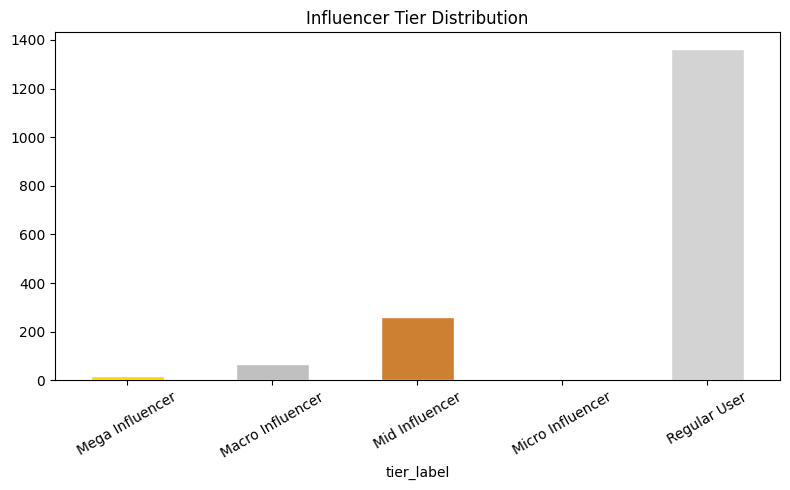

In [ ]:
# ── Tier Assignment ────────────────────────────────────────────────────────────
# Tier Definitions (by percentile):
#   Tier 1 — Mega Influencer  : Top 1%
#   Tier 2 — Macro Influencer : Top 5% (excl T1)
#   Tier 3 — Mid Influencer   : Top 20% (excl T2)
#   Tier 4 — Micro Influencer : Top 50% (excl T3)
#   Tier 5 — Regular User     : Bottom 50%

def assign_tier(percentile):
    if percentile >= 99:   return 1
    elif percentile >= 95: return 2
    elif percentile >= 80: return 3
    elif percentile >= 50: return 4
    else:                  return 5

TIER_LABELS = {
    1: 'Mega Influencer',
    2: 'Macro Influencer',
    3: 'Mid Influencer',
    4: 'Micro Influencer',
    5: 'Regular User'
}

centrality_df['tier'] = centrality_df['influence_percentile'].apply(assign_tier)
centrality_df['tier_label'] = centrality_df['tier'].map(TIER_LABELS)

# Tier distribution
tier_counts = centrality_df['tier_label'].value_counts()
print('Influencer Tier Distribution:')
print(tier_counts.to_string())

fig, ax = plt.subplots(figsize=(8, 5))
tier_order = list(TIER_LABELS.values())
tier_colors = ['#FFD700', '#C0C0C0', '#CD7F32', '#87CEEB', '#D3D3D3']
tier_counts.reindex(tier_order).plot(kind='bar', ax=ax, color=tier_colors, edgecolor='white')
ax.set_title('Influencer Tier Distribution')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
# plt.savefig('../data/processed/sna_tier_distribution.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Louvain Community Detection ────────────────────────────────────────────────
# Why Louvain?
#   - Best modularity optimization algorithm
#   - O(n log n) time complexity → scalable
#   - Handles weighted graphs
#   - Industry standard for social network communities

print('Running Louvain community detection...')
partition = community_louvain.best_partition(G_undirected, weight='weight', random_state=42)

n_communities = len(set(partition.values()))
modularity = community_louvain.modularity(partition, G_undirected, weight='weight')

print(f'Communities detected : {n_communities}')
print(f'Modularity score     : {modularity:.4f}')
print(f'  (Good modularity: > 0.3, Excellent: > 0.5)')

# Add community to centrality df
centrality_df['community_id'] = centrality_df['username'].map(partition)

# Community sizes
community_sizes = pd.Series(partition).value_counts().sort_values(ascending=False)
print(f'\nCommunity sizes:')
print(community_sizes.head(20).to_string())

Running Louvain community detection...
Communities detected : 1399
Modularity score     : 0.1069
  (Good modularity: > 0.3, Excellent: > 0.5)

Community sizes:
270     140
247      77
137      21
631      12
111      10
150       9
262       7
706       5
792       5
401       4
1373      3
59        3
649       3
905       3
149       2
437       2
499       2
407       2
108       2
566       2


In [ ]:
# ── Community Profiling ────────────────────────────────────────────────────────
community_profiles = []

for comm_id, size in community_sizes.items():
    comm_users = centrality_df[centrality_df['community_id'] == comm_id]

    # Top influencer in community
    top_user = comm_users.sort_values('influence_score', ascending=False).iloc[0]

    # Dominant sentiment (from original data)
    comm_posts = df[df['username'].isin(comm_users['username'])]
    if 'sentiment_label' in comm_posts.columns and len(comm_posts) > 0:
        dominant_sentiment = comm_posts['sentiment_label'].mode().iloc[0] if len(comm_posts) > 0 else 'unknown'
    else:
        dominant_sentiment = 'unknown'

    # Dominant keyword
    if 'keyword' in comm_posts.columns and len(comm_posts) > 0:
        dominant_keyword = comm_posts['keyword'].mode().iloc[0] if len(comm_posts) > 0 else 'unknown'
    else:
        dominant_keyword = 'unknown'

    community_profiles.append({
        'community_id': int(comm_id),
        'size': size,
        'top_influencer': top_user['username'],
        'top_influence_score': round(float(top_user['influence_score']), 6),
        'avg_influence_score': round(float(comm_users['influence_score'].mean()), 6),
        'avg_total_interaction': round(float(comm_users['total_interaction'].fillna(0).mean()), 2),
        'dominant_sentiment': dominant_sentiment,
        'dominant_keyword': dominant_keyword,
        'total_posts': len(comm_posts),
    })

community_profiles_df = pd.DataFrame(community_profiles)
print('Community Profiles (Top 10 largest):')
print(community_profiles_df.head(10).to_string(index=False))

Community Profiles (Top 10 largest):
 community_id  size  top_influencer  top_influence_score  avg_influence_score  avg_total_interaction dominant_sentiment dominant_keyword  total_posts
          270   140 wirausaha.mapan             0.652267             0.233152                   0.00           Positive     KrisisEnergi          303
          247    77     wargasesama             0.569731             0.188779                   0.00           Positive       SubsidiBBM          243
          137    21         prabowo             0.225390             0.019318                   0.57           Negative   ProduksiMinyak            8
          631    12       pertamina             0.006823             0.002258                   0.00           Negative       SubsidiBBM           14
          111    10       sindonews             0.064797             0.023440                   0.60            Neutral     KrisisEnergi           44
          150     9 riyan.nurrahman             0.029156       

In [ ]:
MIN_EDGE_WEIGHT = 2

edges_filtered = [
    (u, v, d)
    for u, v, d in G_undirected.edges(data=True)
    if d.get("weight", 1) >= MIN_EDGE_WEIGHT
]

G_undirected = nx.Graph()
G_undirected.add_edges_from(edges_filtered)

In [ ]:
# ── White Space Analysis (Revised & Robust) ───────────────────────────────────

import pandas as pd
import numpy as np

whitespace_results = {}

# ─────────────────────────────────────────────
# 1) KEYWORD WHITE SPACE
# ─────────────────────────────────────────────

if 'keyword' in df.columns:

    kw_analysis = (
        df
        .groupby('keyword')
        .agg(
            total_posts=('username', 'count'),
            unique_users=('username', 'nunique'),
            avg_interaction=('total_interaction', 'mean'),
            total_interaction=('total_interaction', 'sum'),
            pct_negative=(
                'sentiment_label',
                lambda x: (
                    x.str.lower() == 'negative'
                ).mean() * 100
            ),
            pct_positive=(
                'sentiment_label',
                lambda x: (
                    x.str.lower() == 'positive'
                ).mean() * 100
            ),
        )
        .reset_index()
    )

    kw_analysis['interaction_per_user'] = (
        kw_analysis['avg_interaction']
        /
        kw_analysis['unique_users'].clip(lower=1)
    )

    print('\nKeyword-level White Space Analysis:')
    print(
        kw_analysis
        .sort_values(
            'interaction_per_user',
            ascending=False
        )
        .to_string(index=False)
    )

    whitespace_results['keyword_analysis'] = (
        kw_analysis.to_dict('records')
    )


# ─────────────────────────────────────────────
# 2) COMMUNITY ISOLATION (FIXED)
# ─────────────────────────────────────────────

isolated_communities = []

for comm_id in community_sizes.index:

    comm_nodes = [
        n
        for n, c in partition.items()
        if c == comm_id
    ]

    if len(comm_nodes) < 2:
        continue

    subgraph = G_undirected.subgraph(comm_nodes)

    internal_edges = subgraph.number_of_edges()

    # FIX: safe degree calculation

    total_degree = sum(
        int(G_undirected.degree[n])
        for n in comm_nodes
        if n in G_undirected
    )

    total_edges = total_degree / 2

    isolation_ratio = (
        internal_edges
        /
        max(total_edges, 1)
    )

    isolated_communities.append({
        'community_id': int(comm_id),
        'size': int(community_sizes[comm_id]),
        'internal_edges': int(internal_edges),
        'total_edges': int(total_edges),
        'isolation_ratio': round(
            isolation_ratio,
            4
        ),
        'is_isolated': isolation_ratio > 0.9
    })


isolated_df = pd.DataFrame(isolated_communities)

print(
    '\nHighly isolated communities (ratio > 0.9):',
    int(isolated_df["is_isolated"].sum())
)

print(
    isolated_df[
        isolated_df["is_isolated"]
    ].sort_values(
        "size",
        ascending=False
    ).to_string(index=False)
)

whitespace_results[
    'isolated_communities'
] = isolated_df.to_dict('records')


Keyword-level White Space Analysis:
         keyword  total_posts  unique_users  avg_interaction  total_interaction  pct_negative  pct_positive  interaction_per_user
  ProduksiMinyak          879           820         1.878271               1651     37.656428     22.980660              0.002291
 HargaMinyakBumi            1             1         0.000000                  0      0.000000      0.000000              0.000000
     KonsumsiBBM            6             6         0.000000                  0      0.000000     50.000000              0.000000
KenaikanhargaBBM           36            26         0.000000                  0      8.333333     13.888889              0.000000
    KrisisEnergi          500           399         0.000000                  0     28.000000     46.600000              0.000000
 MinyakIndonesia           15            14         0.000000                  0      0.000000     66.666667              0.000000
      SubsidiBBM          278           234         0

In [ ]:
# ── Build Interactive Network with Pyvis (Revised & Robust) ───────────────────

from pyvis.network import Network
import pandas as pd
import os
import numpy as np

# ── Helper functions (handle NaN safely)

def safe_int(x):
    if pd.isna(x):
        return 0
    return int(x)

def safe_float(x):
    if pd.isna(x):
        return 0.0
    return float(x)


# ── Optional: clean NaN once (recommended)

centrality_df = centrality_df.fillna(0)


# ── Select top nodes

top_nodes = (
    centrality_df
    .sort_values("influence_score", ascending=False)
    .head(TOP_N_NODES)["username"]
    .tolist()
)

G_viz = G_undirected.subgraph(top_nodes).copy()


# ── Color map

community_colors = [
    '#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6',
    '#1ABC9C','#E67E22','#34495E','#F1C40F','#16A085',
    '#8E44AD','#27AE60','#D35400','#2980B9','#C0392B',
]

tier_colors_map = {
    1: '#FFD700',
    2: '#C0C0C0',
    3: '#CD7F32',
    4: '#87CEEB',
    5: '#D3D3D3'
}


# ── Initialize network

net = Network(
    height="750px",
    width="100%",
    bgcolor="#1a1a2e",
    font_color="white",
    directed=False
)

net.barnes_hut(
    gravity=-8000,
    central_gravity=0.3,
    spring_length=100
)


# ── Add nodes

for node in G_viz.nodes():

    row = centrality_df[
        centrality_df["username"] == node
    ]

    if row.empty:
        continue

    row = row.iloc[0]

    # Handle community naming differences
    comm_id = safe_int(
        row.get("community_id",
        row.get("community", 0))
    )

    color = community_colors[
        comm_id % len(community_colors)
    ]

    tier = safe_int(
        row.get("tier", 5)
    )

    influence = safe_float(
        row.get("influence_score", 0)
    )

    size = 10 + influence * 60


    # Tooltip

    title = f"""
    <b>@{node}</b><br>
    Tier: {row.get('tier_label', 'Unknown')}<br>
    Influence Score: {safe_float(row.get('influence_score', 0)):.4f}<br>
    PageRank: {safe_float(row.get('pagerank', 0)):.6f}<br>
    Betweenness: {safe_float(row.get('betweenness_centrality', 0)):.6f}<br>
    Posts: {safe_int(row.get('post_count', 0))}<br>
    Total Interaction: {safe_int(row.get('total_interaction', 0)):,}<br>
    Community: {comm_id}
    """

    net.add_node(
        node,
        label=node if tier <= 3 else "",
        title=title,
        size=max(size, 5),
        color=color,
        borderWidth=3 if tier == 1 else 1,
        borderWidthSelected=5,
    )


# ── Add edges

for u, v, data in G_viz.edges(data=True):

    weight = safe_float(
        data.get("weight", 1)
    )

    net.add_edge(
        u,
        v,
        value=min(weight, 10),
        color="rgba(255,255,255,0.1)"
    )


# ── Ensure output directory exists

out_path = "../data/processed/network_visualization.html"

os.makedirs(
    os.path.dirname(out_path),
    exist_ok=True
)


# ── Save

net.save_graph(out_path)

print(f"✅ Interactive network saved: {out_path}")
print(
    f"   Nodes shown: {G_viz.number_of_nodes()}, "
    f"Edges: {G_viz.number_of_edges()}"
)

✅ Interactive network saved: ../data/processed/network_visualization.html
   Nodes shown: 100, Edges: 4875


In [ ]:
print("Nodes:", G_undirected.number_of_nodes())
print("Edges:", G_undirected.number_of_edges())

Nodes: 229
Edges: 17786


In [ ]:
import networkx as nx

TOP_N_NODES = 120
MIN_EDGE_WEIGHT = 2

# 1 — Select most important nodes

top_nodes = (
    centrality_df
    .sort_values("influence_score", ascending=False)
    .head(TOP_N_NODES)["username"]
)

G_viz = G_undirected.subgraph(top_nodes).copy()


# 2 — Filter weak edges

edges_filtered = [
    (u, v, d)
    for u, v, d in G_viz.edges(data=True)
    if d.get("weight", 1) >= MIN_EDGE_WEIGHT
]

G_viz = nx.Graph()
G_viz.add_edges_from(edges_filtered)


# 3 — Keep largest component only

if G_viz.number_of_nodes() > 0:

    largest_cc = max(
        nx.connected_components(G_viz),
        key=len
    )

    G_viz = G_viz.subgraph(largest_cc).copy()


# Debug

print("Nodes:", G_viz.number_of_nodes())
print("Edges:", G_viz.number_of_edges())
print("Density:", nx.density(G_viz))

Nodes: 120
Edges: 6761
Density: 0.9469187675070028


In [ ]:
import numpy as np
import networkx as nx

# ── BACKBONE FILTER ─────────────────────────

weights = [
    d.get("weight", 1)
    for _, _, d in G_undirected.edges(data=True)
]

threshold = np.percentile(weights, 75)

print("Weight threshold:", threshold)

edges_backbone = [
    (u, v, d)
    for u, v, d in G_undirected.edges(data=True)
    if d.get("weight", 1) >= threshold
]

G_backbone = nx.Graph()
G_backbone.add_edges_from(edges_backbone)

print("Nodes:", G_backbone.number_of_nodes())
print("Edges:", G_backbone.number_of_edges())
print("Density:", nx.density(G_backbone))

Weight threshold: 2.0
Nodes: 229
Edges: 17786
Density: 0.6812993181644067


In [ ]:
largest_comm = (
    centrality_df["community_id"]
    .value_counts()
    .index[0]
)

nodes_comm = [
    n
    for n in G_undirected.nodes()
    if partition.get(n) == largest_comm
]

G_comm = G_undirected.subgraph(nodes_comm).copy()

print("Nodes:", G_comm.number_of_nodes())
print("Edges:", G_comm.number_of_edges())

Nodes: 136
Edges: 9046


In [ ]:
top_user = (
    centrality_df
    .sort_values("influence_score", ascending=False)
    .iloc[0]["username"]
)

G_ego = nx.ego_graph(
    G_undirected,
    top_user,
    radius=1
)

print("Center:", top_user)
print("Nodes:", G_ego.number_of_nodes())
print("Edges:", G_ego.number_of_edges())

Center: wirausaha.mapan
Nodes: 182
Edges: 16471


In [ ]:
from pyvis.network import Network

net = Network(
    height="750px",
    width="100%",
    bgcolor="#1a1a2e",
    font_color="white"
)

net.barnes_hut(
    gravity=-5000,
    spring_length=120
)

for node in G_backbone.nodes():

    net.add_node(
        node,
        label=node,
        size=10
    )

for u, v, d in G_backbone.edges(data=True):

    net.add_edge(
        u,
        v,
        value=min(d.get("weight", 1), 5)
    )

net.save_graph("network_backbone.html")

print("Saved: network_backbone.html")

Saved: network_backbone.html


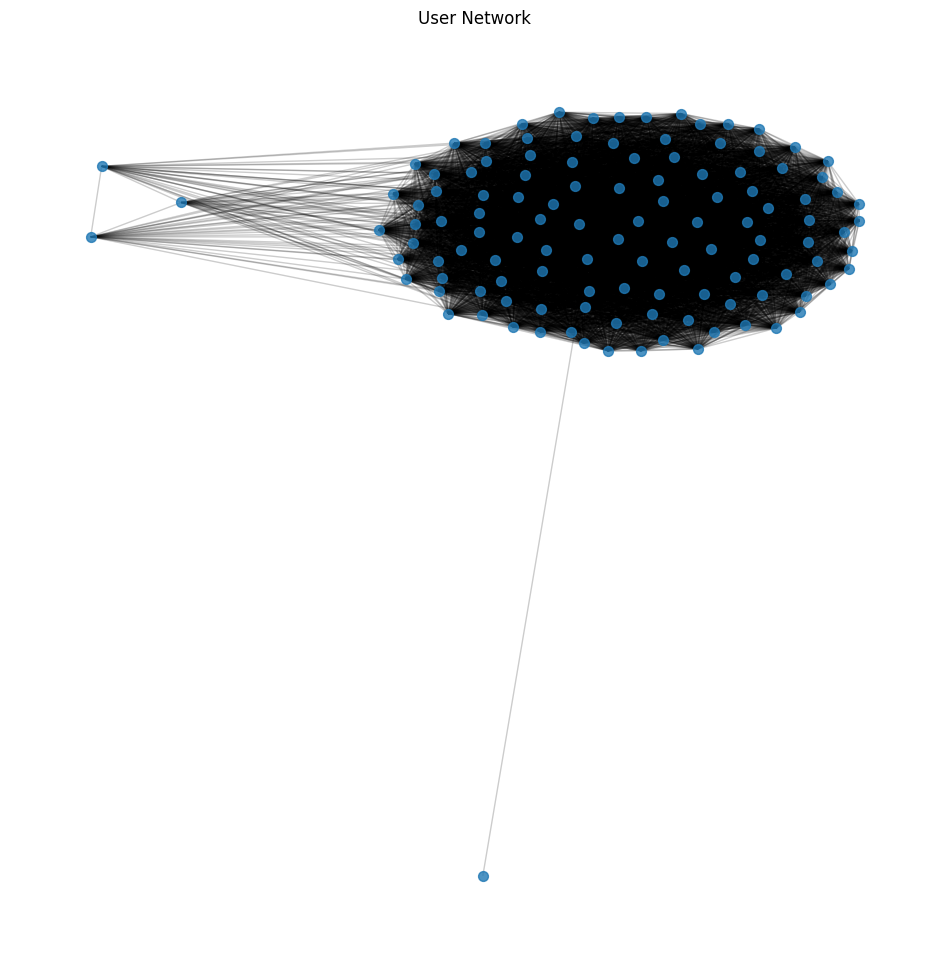

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(12, 12))

# layout stabil
pos = nx.spring_layout(
    G_viz,
    k=0.15,
    iterations=50,
    seed=42
)

nx.draw_networkx_nodes(
    G_viz,
    pos,
    node_size=50,
    alpha=0.8
)

nx.draw_networkx_edges(
    G_viz,
    pos,
    alpha=0.2
)

plt.title("User Network")
plt.axis("off")

plt.show()

In [ ]:
external_targets = (
    set(edges_df["target"])
    - set(df["username"])
)

list(external_targets)[:20]

['jak101fm',
 'pertamina.foundation',
 'kemenhub151',
 'aktualforum',
 'beldocuanfreeforum',
 'alif.m.ismail',
 'potus',
 'whitehouse',
 'purbayayudhi.official',
 'aden_achmad_me',
 'yuliawati.792',
 'ppidunia',
 'fao',
 'gibran_rakabuming',
 'mamet_yadi2808',
 'yair_netanyahu',
 'matanajwa',
 'gojekindonesia',
 'esdm_ri',
 'hanzizar']

In [ ]:
edges_df[
    ["source", "target"]
].drop_duplicates()

,source,target
0,350id,bahlillahadalia
1,350id,haniffaisolnurofiq
2,350id,prabowo
3,________naba,riyan.nurrahman
4,aan101425,prabowo
...,...,...
94,validnews,visitelitisaksama
95,wily_setia30,whitehouse
96,yurikaputri067,investordailyid
97,zamzam.f,ukmpenelitianuny


In [ ]:
# ── Count mentions per source → target ─────────────────────────────

mention_counts = (
    edges_df
    .groupby(["source", "target"])
    .size()
    .reset_index(name="n_mentions")
    .sort_values("n_mentions", ascending=False)
)

print(
    mention_counts
    .head(20)
    .to_string(index=False)
)

            source               target  n_mentions
             350id      bahlillahadalia           1
             350id   haniffaisolnurofiq           1
             350id              prabowo           1
      ________naba      riyan.nurrahman           1
         aan101425              prabowo           1
           aelav.u        yuliawati.792           1
         aktualcom          aktualforum           1
     arafatsaid765              sorotan           1
         ashza_ras      riyan.nurrahman           1
 aulia.rahmawati84         energinewsid           1
 aulia.rahmawati84                kesdm           1
 aulia.rahmawati84            pertamina           1
 aulia.rahmawati84 pertamina.foundation           1
 aulia.rahmawati84  pertaminapatraniaga           1
 aulia.rahmawati84         storyrakyat_           1
 aulia.rahmawati84          voxnetizens           1
 aulia.rahmawati84         wartaekonomi           1
        bangleo.fx            vzn_iqbal           1
basyiriskand

In [ ]:
n_edges = (
    edges_df[
        ["source", "target"]
    ]
    .drop_duplicates()
    .shape[0]
)

print(n_edges)

99


In [ ]:
print(
    "Max total_interaction:",
    df["total_interaction"].max()
)

Max total_interaction: 131


In [ ]:
max_value = df["total_interaction"].max()

max_rows = df[
    df["total_interaction"] == max_value
]

print("Max total_interaction:", max_value)

print(
    max_rows[
        [
            "post_id",
            "username",
            "total_interaction",
            "total_like",
            "date"
        ]
    ]
)

Max total_interaction: 131
          post_id    username  total_interaction  total_like  \
1576  DV-MbYoERU5  ronnypunya                131        1982   

                          date  
1576 2026-03-17 04:21:35+00:00  


In [ ]:
# ── Max comment per post ─────────────────────────────────────

comments_per_post = (
    df[
        df["is_comment"] == True
    ]
    .groupby("post_id")["comment_id"]
    .count()
)

max_comments = comments_per_post.max()

print("Max comments per post:", max_comments)

Max comments per post: 10


In [ ]:
# ── Build Co-Keyword Edges (time-windowed) ─────────────────────────────────────

import pandas as pd
from pathlib import Path

if "keyword" in df.columns:

    TIME_WINDOW_DAYS = 7
    edges_cokw = []

    # Ensure date is datetime
    df["date"] = pd.to_datetime(
        df["date"],
        errors="coerce"
    )

    for keyword, group in df.groupby("keyword"):

        group_sorted = (
            group
            .sort_values("date")
            [["username", "date", "total_interaction"]]
            .dropna(subset=["date"])
        )

        users = group_sorted.values

        for i in range(len(users)):

            u1, d1, w1 = users[i]

            for j in range(i + 1, len(users)):

                u2, d2, w2 = users[j]

                if u1 == u2:
                    continue

                delta_days = abs(
                    (d2 - d1).days
                )

                if delta_days <= TIME_WINDOW_DAYS:

                    weight = (
                        (w1 if pd.notna(w1) else 0)
                        + (w2 if pd.notna(w2) else 0)
                    ) / 2

                    edges_cokw.append({
                        "source": str(u1).lower(),
                        "target": str(u2).lower(),
                        "keyword": keyword,
                        "weight": weight,
                        "type": "co_keyword"
                    })

                else:
                    break

    if len(edges_cokw) > 0:

        edges_cokw_df = pd.DataFrame(edges_cokw)

        edges_cokw_agg = (
            edges_cokw_df
            .groupby(["source", "target"])
            .agg(
                weight=("weight", "mean"),
                co_keyword_count=("keyword", "count")
            )
            .reset_index()
            .sort_values(
                "co_keyword_count",
                ascending=False
            )
        )

        print(
            f"Co-keyword edges (time-windowed): "
            f"{len(edges_cokw_agg):,}"
        )

        # ── SAFE SAVE ─────────────────────────

        output_dir = Path("output")
        output_dir.mkdir(exist_ok=True)

        file_path = (
            output_dir /
            "edges_cokeyword.csv"
        )

        edges_cokw_agg.to_csv(
            file_path,
            index=False
        )

        print(
            f"✅ Saved to {file_path}"
        )

    else:

        print(
            "No co-keyword edges found "
            "within time window"
        )

Co-keyword edges (time-windowed): 327,478
✅ Saved to output\edges_cokeyword.csv


In [ ]:
pd.set_option("display.max_columns", None)

# -----------------------------------------
# 3. BASIC DATA INSPECTION
# -----------------------------------------

print("\nINFO DATASET:")
df.info()

print("\nDESCRIBE NUMERICAL:")
df.describe()

print("\nMISSING VALUES:")
missing = df.isnull().sum().sort_values(ascending=False)
print(missing)


INFO DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2215 entries, 0 to 2214
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   date               2215 non-null   datetime64[ns, UTC]
 1   keyword            2215 non-null   object             
 2   url                2215 non-null   object             
 3   content            2129 non-null   object             
 4   username           2215 non-null   object             
 5   total_like         2215 non-null   int64              
 6   total_interaction  2215 non-null   int64              
 7   content_processed  2069 non-null   object             
 8   sentiment_label    2215 non-null   object             
 9   sentiment_score    2215 non-null   float64            
 10  post_id            2215 non-null   object             
 11  comment_id         2215 non-null   object             
 12  is_comment         2215 non-null 

In [ ]:

pd.set_option("display.max_columns", None)

# -----------------------------------------
# 3. BASIC DATA INSPECTION
# -----------------------------------------

print("\nINFO DATASET:")
df.info()

print("\nDESCRIBE NUMERICAL:")
df.describe()

print("\nMISSING VALUES:")
missing = df.isnull().sum().sort_values(ascending=False)
print(missing)


INFO DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2215 entries, 0 to 2214
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   date               2215 non-null   datetime64[ns, UTC]
 1   keyword            2215 non-null   object             
 2   url                2215 non-null   object             
 3   content            2129 non-null   object             
 4   username           2215 non-null   object             
 5   total_like         2215 non-null   int64              
 6   total_interaction  2215 non-null   int64              
 7   content_processed  2069 non-null   object             
 8   sentiment_label    2215 non-null   object             
 9   sentiment_score    2215 non-null   float64            
 10  post_id            2215 non-null   object             
 11  comment_id         2215 non-null   object             
 12  is_comment         2215 non-null 

In [ ]:
# ── Save Final Clean Dataset + Metadata (Revised) ──────────────────────────

from pathlib import Path
import pandas as pd
from datetime import datetime

# Create output directory
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

# ── Copy dataframe ─────────────────────────────────────────────────────────

df_clean = df.copy()

# ── Remove hashtags_str column (as requested) ─────────────────────────────

if "hashtags_str" in df_clean.columns:

    df_clean = df_clean.drop(
        columns=["hashtags_str"]
    )

# ── Convert total_like to integer safely ───────────────────────────────────

if "total_like" in df_clean.columns:

    df_clean["total_like"] = (
        pd.to_numeric(
            df_clean["total_like"],
            errors="coerce"
        )
        .fillna(0)
        .astype("int64")
    )

# ── Convert list columns to string (CSV-safe) ─────────────────────────────

list_columns = [
    "mentions",
    "hashtags"
]

for col in list_columns:

    if col in df_clean.columns:

        df_clean[col] = df_clean[col].apply(
            lambda x: "|".join(
                map(str, x)
            )
            if isinstance(x, list)
            else ""
        )

# ── Convert period column ─────────────────────────────────────────────────

if "year_month" in df_clean.columns:

    df_clean["year_month"] = (
        df_clean["year_month"]
        .astype(str)
    )

# ── Convert datetime column ──────────────────────────────────────────────

if "date" in df_clean.columns:

    df_clean["date"] = (
        df_clean["date"]
        .astype(str)
    )

# ── Save dataset ─────────────────────────────────────────────────────────

dataset_file = output_dir / "dataset_final_clean_revised.csv"

df_clean.to_csv(
    dataset_file,
    index=False,
    encoding="utf-8"
)

print("✅ Dataset saved")
print("Shape:", df_clean.shape)
print("Location:", dataset_file)

# ── Create metadata ──────────────────────────────────────────────────────

meta_file = output_dir / "dataset_metadata_revised.txt"

now = datetime.now().strftime(
    "%Y-%m-%d %H:%M:%S"
)

with open(meta_file, "w", encoding="utf-8") as f:

    f.write("DATASET METADATA REPORT\n")
    f.write("=" * 60 + "\n")

    f.write(f"Generated at : {now}\n\n")

    # Shape
    f.write("DATASET SHAPE\n")
    f.write("-" * 60 + "\n")
    f.write(f"Rows    : {df_clean.shape[0]}\n")
    f.write(f"Columns : {df_clean.shape[1]}\n\n")

    # Column types
    f.write("COLUMN TYPES\n")
    f.write("-" * 60 + "\n")

    f.write(
        df_clean.dtypes.to_string()
    )

    f.write("\n\n")

    # Missing values
    f.write("MISSING VALUES\n")
    f.write("-" * 60 + "\n")

    f.write(
        df_clean
        .isnull()
        .sum()
        .sort_values(ascending=False)
        .to_string()
    )

    f.write("\n\n")

    # Numerical summary
    f.write("NUMERICAL SUMMARY\n")
    f.write("-" * 60 + "\n")

    try:

        f.write(
            df_clean
            .describe()
            .to_string()
        )

    except:

        f.write(
            "No numerical summary available"
        )

    f.write("\n\n")

    # Key stats
    f.write("KEY DATASET STATS\n")
    f.write("-" * 60 + "\n")

    if "username" in df_clean.columns:

        f.write(
            f"Unique usernames : "
            f"{df_clean['username'].nunique()}\n"
        )

    if "post_id" in df_clean.columns:

        f.write(
            f"Unique posts : "
            f"{df_clean['post_id'].nunique()}\n"
        )

    if "comment_id" in df_clean.columns:

        f.write(
            f"Unique comments : "
            f"{df_clean['comment_id'].nunique()}\n"
        )

    if "n_mentions" in df_clean.columns:

        f.write(
            f"Total mentions : "
            f"{df_clean['n_mentions'].sum()}\n"
        )

    if "n_hashtags" in df_clean.columns:

        f.write(
            f"Total hashtags : "
            f"{df_clean['n_hashtags'].sum()}\n"
        )

print("📄 Metadata saved")
print("Location:", meta_file)


✅ Dataset saved
Shape: (2215, 20)
Location: output\dataset_final_clean_revised.csv
📄 Metadata saved
Location: output\dataset_metadata_revised.txt


In [ ]:
# ── Save Final Clean Dataset + Metadata (Final with Datetime TZ) ─────────

from pathlib import Path
import pandas as pd
from datetime import datetime

# ── Create output directory ──────────────────────────────────────────────

output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

# ── Copy dataframe ───────────────────────────────────────────────────────

df_clean = df.copy()

# ── Remove hashtags_str column ───────────────────────────────────────────

if "hashtags_str" in df_clean.columns:

    df_clean = df_clean.drop(
        columns=["hashtags_str"]
    )

# ── Convert total_like to integer safely ─────────────────────────────────

if "total_like" in df_clean.columns:

    df_clean["total_like"] = (
        pd.to_numeric(
            df_clean["total_like"],
            errors="coerce"
        )
        .fillna(0)
        .astype("int64")
    )

# ── Convert list columns to string (CSV-safe) ────────────────────────────

list_columns = [
    "mentions",
    "hashtags"
]

for col in list_columns:

    if col in df_clean.columns:

        df_clean[col] = df_clean[col].apply(
            lambda x: "|".join(map(str, x))
            if isinstance(x, list)
            else ""
        )

# ── Convert year_month column ────────────────────────────────────────────

if "year_month" in df_clean.columns:

    df_clean["year_month"] = (
        df_clean["year_month"]
        .astype(str)
    )

# ── Convert date column to DATETIME with timezone ───────────────────────

if "date" in df_clean.columns:

    df_clean["date"] = pd.to_datetime(
        df_clean["date"],
        errors="coerce",
        utc=True
    )

# ── Validate datetime conversion ─────────────────────────────────────────

if "date" in df_clean.columns:

    print("\nDATE COLUMN INFO")
    print("----------------------------")

    print("dtype :", df_clean["date"].dtype)

    print(
        "missing datetime :",
        df_clean["date"].isnull().sum()
    )

# ── Sort by datetime (best practice for temporal analysis) ───────────────

if "date" in df_clean.columns:

    df_clean = df_clean.sort_values(
        by="date"
    )

# ── Save dataset ─────────────────────────────────────────────────────────

dataset_file = output_dir / "dataset_final_clean_revised.csv"

df_clean.to_csv(
    dataset_file,
    index=False,
    encoding="utf-8"
)

print("\n✅ Dataset saved")
print("Shape:", df_clean.shape)
print("Location:", dataset_file)

# ── Create metadata ─────────────────────────────────────────────────────

meta_file = output_dir / "dataset_metadata_revised.txt"

now = datetime.now().strftime(
    "%Y-%m-%d %H:%M:%S"
)

with open(meta_file, "w", encoding="utf-8") as f:

    f.write("DATASET METADATA REPORT\n")
    f.write("=" * 60 + "\n")

    f.write(f"Generated at : {now}\n\n")

    # Shape
    f.write("DATASET SHAPE\n")
    f.write("-" * 60 + "\n")

    f.write(
        f"Rows    : {df_clean.shape[0]}\n"
    )

    f.write(
        f"Columns : {df_clean.shape[1]}\n\n"
    )

    # Column types
    f.write("COLUMN TYPES\n")
    f.write("-" * 60 + "\n")

    f.write(
        df_clean.dtypes.to_string()
    )

    f.write("\n\n")

    # Missing values
    f.write("MISSING VALUES\n")
    f.write("-" * 60 + "\n")

    f.write(
        df_clean
        .isnull()
        .sum()
        .sort_values(
            ascending=False
        )
        .to_string()
    )

    f.write("\n\n")

    # Numerical summary
    f.write("NUMERICAL SUMMARY\n")
    f.write("-" * 60 + "\n")

    try:

        f.write(
            df_clean
            .describe()
            .to_string()
        )

    except:

        f.write(
            "No numerical summary available"
        )

    f.write("\n\n")

    # Key stats
    f.write("KEY DATASET STATS\n")
    f.write("-" * 60 + "\n")

    if "username" in df_clean.columns:

        f.write(
            f"Unique usernames : "
            f"{df_clean['username'].nunique()}\n"
        )

    if "post_id" in df_clean.columns:

        f.write(
            f"Unique posts : "
            f"{df_clean['post_id'].nunique()}\n"
        )

    if "comment_id" in df_clean.columns:

        f.write(
            f"Unique comments : "
            f"{df_clean['comment_id'].nunique()}\n"
        )

    if "n_mentions" in df_clean.columns:

        f.write(
            f"Total mentions : "
            f"{df_clean['n_mentions'].sum()}\n"
        )

    if "n_hashtags" in df_clean.columns:

        f.write(
            f"Total hashtags : "
            f"{df_clean['n_hashtags'].sum()}\n"
        )

print("\n📄 Metadata saved")
print("Location:", meta_file)


DATE COLUMN INFO
----------------------------
dtype : datetime64[ns, UTC]
missing datetime : 0

✅ Dataset saved
Shape: (2215, 20)
Location: output\dataset_final_clean_revised.csv

📄 Metadata saved
Location: output\dataset_metadata_revised.txt
